# Comparing methods of feature engineering through detecting the anomalous activity of a ship’s engine

<br></br>

## **Business context**
We are provided with a real data set to identify anomalous activity in a ship’s engine functionality (Devabrat,  2022). Typically speaking, anomalies would make up a minority of the data points (i.e., about 1% to 5% of the data points would be anomalies).

The data set contains six important features continuously monitored to evaluate the engine's status as ‘good’ or ‘bad’. These features are:
- **Engine rpm (revolutions per minute):** A high rpm indicates the engine is operating at a higher speed than designed for prolonged periods, which can lead to overheating, excessive wear, and eventual failure. A low rpm could signal a lack of power, issues with fuel delivery, or internal mechanical problems.
- **Lubrication oil pressure:** Low lubrication oil pressure indicates insufficient lubrication, leading to increased friction, overheating, and engine damage. A high lubrication oil pressure could signal a blockage in the oil delivery system, potentially causing seal or gasket failure.
- **Fuel pressure:** High fuel pressure can cause poor engine performance and incomplete combustion, indicating fuel pump or filter issues. A low fuel pressure may result in excessive fuel consumption, poor emissions, or damage to the fuel injectors.
- **Coolant pressure:** Low coolant pressure indicates a potential leak in the cooling system or a coolant pump failure, risking engine overheating. A high coolant pressure could be a sign of a blockage in the cooling system or a failing head gasket, which can also lead to overheating.
- **Lubrication oil temperature:** High lubrication oil temperature suggests the oil is overheating, which can degrade its lubricating properties and lead to engine damage. A low lubrication oil temperature may indicate it is not reaching its optimal operating temperature, potentially causing inadequate lubrication.
- **Coolant temperature:** High coolant temperature signals overheating, which various issues, including a failed thermostat, coolant leak, or insufficient coolant flow can cause. A low coolant temperature could suggest the engine is not reaching its optimal operating temperature, affecting performance and efficiency.

Issues with engines could lead to engine malfunctions, potential safety hazards, and downtime (e.g. delayed deliveries), resulting in the breakdown of a ship’s overall functionality, consequently impacting the business, such as affecting revenue via failure to deliver goods. By predicting timely maintenance, the business aims to increase profit by reducing downtime, reducing safety risks for the crew, limiting fuel consumption, and increasing customer satisfaction through timely deliveries.

The task is to develop a robust anomaly detection system to protect a company’s shipping fleet by evaluating engine functionality. Along side this we will compare the effectiveness of simple feature engineering, taking ratios, and feature discovery using symbolic regression.

We will explore some statistical methods and unsupervised ML methods for anomalie detection, intepret the effectiveness of each whilst copmaring thier effect on three different feature sets.

**Methods Used:**
- **Z-Score**
- **BoxPlots**
- **IQR**
- **One Class SVM**
- **IsolationForest**
<br></br>

**Comparions Made Using:**
- **PCA**
- **UMAP**
- **Separation Distance**
<br></br>

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
import ssl, certifi
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

In [52]:
# URL to import data set from GitHub.
url = "https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv"

In [53]:
# Create a pandas dataframe and inspect the first few rows
df = pd.read_csv(url)
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [54]:
# Inspecting a few statistics of the data: mean, std, min and max
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


Each column has 19535 entires, there are no negative values, max value for some columns are significantly higher than the min, but no inf values it seems.

In [55]:
# Now inpecting data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB


In [56]:
# And NA/NaN values
(df.isna()).sum()

Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64

In [57]:
df.duplicated().any()

np.False_

In [58]:
rows_number = df.shape[0]

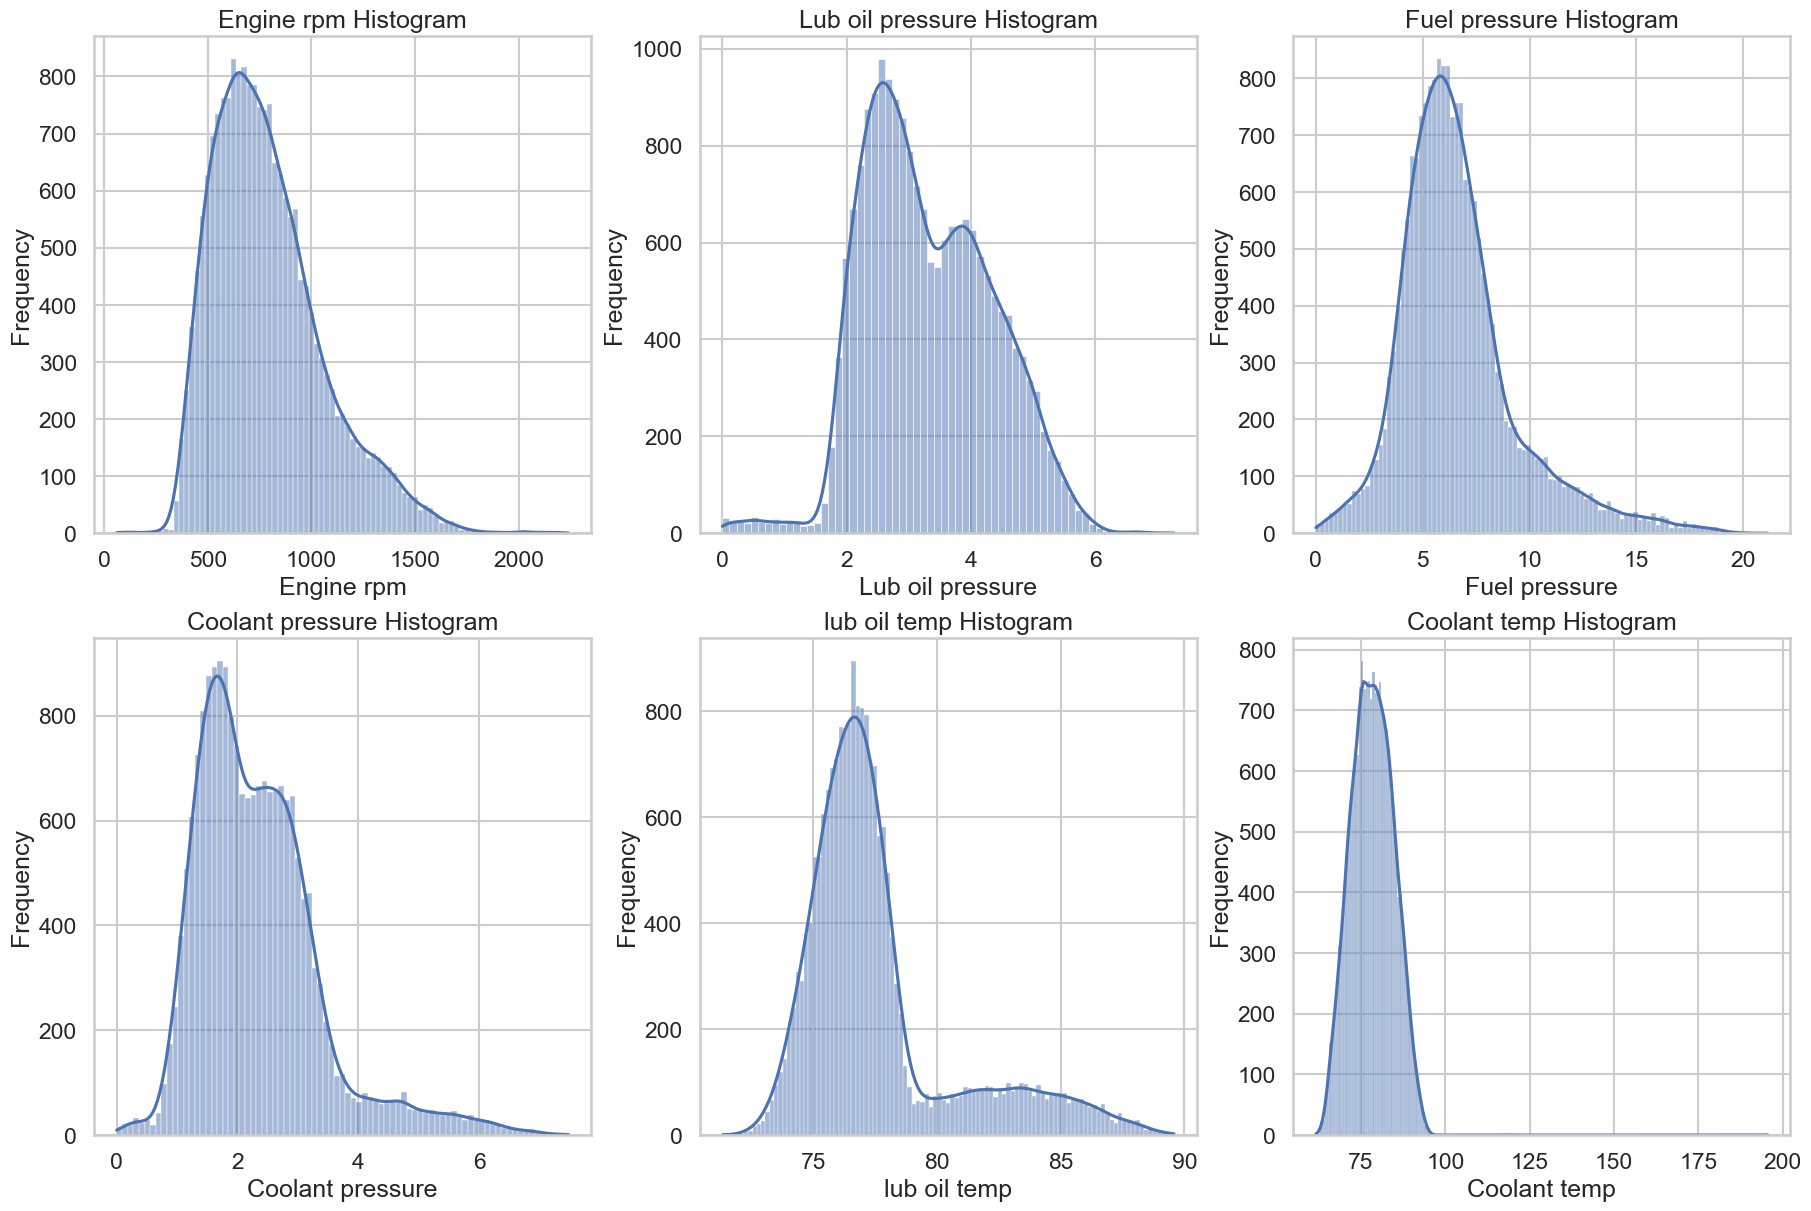

In [59]:
# Inspecting the distribution of each column
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} Histogram")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

The histograms reveal we are working with non-gaussian distributed data.

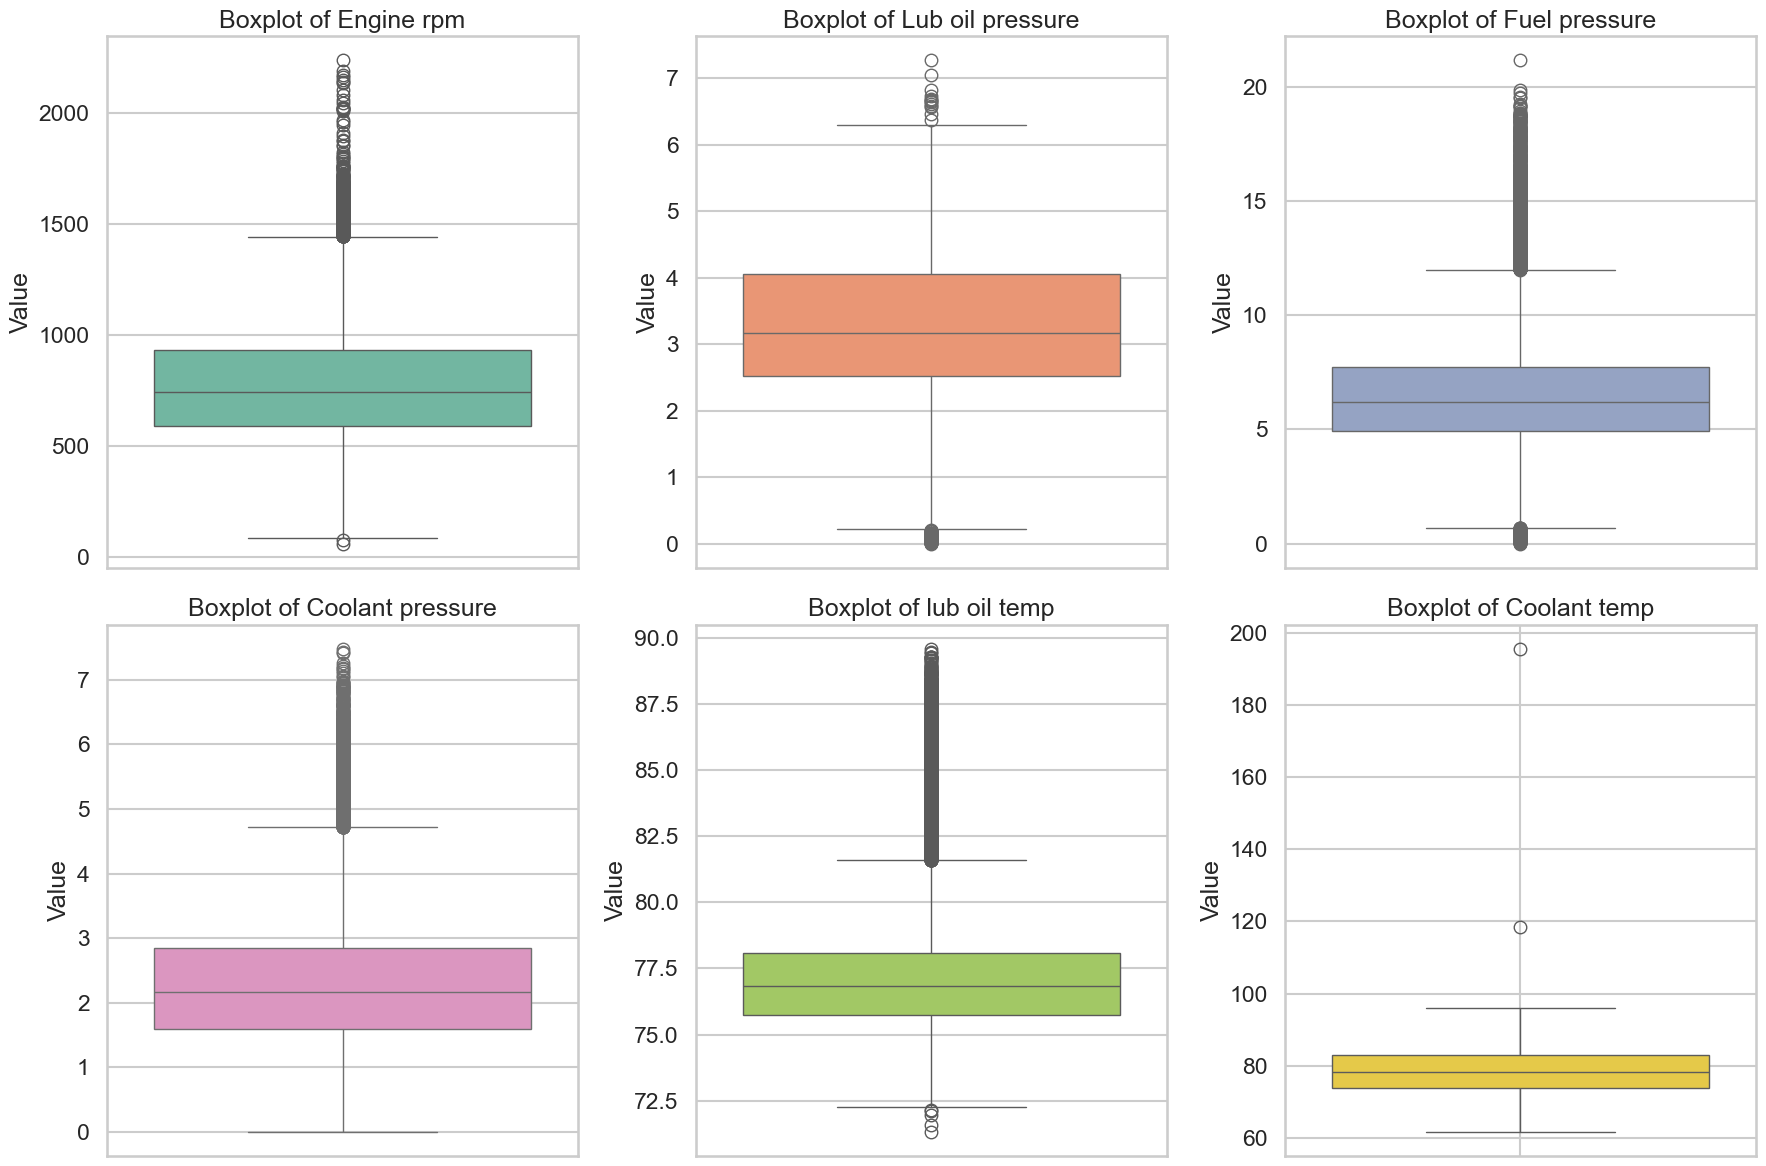

In [60]:
# Boxplot Analysis

# Theme
sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("Set2", n_colors=len(df.columns))

# Subplots
fig, axes = plt.subplots(2, 3, figsize=(18,12))
for i, col in enumerate(df.columns):
    row = i // 3
    col_idx = i % 3
    color = palette[i]
    sns.boxplot(data=df[col], ax=axes[row, col_idx], color=color)
    axes[row, col_idx].set_title(f'Boxplot of {col}')
    axes[row, col_idx].set_ylabel('Value')

plt.tight_layout()
plt.grid(True)
plt.show()

The box plots indicate the presence of outliers in every column, higher and lower than the mean. The density of points seems high for each column with exception of coolant temp, whcih shows only 2 points, both of which are far from the top of the whisker. These two observations could be errors and should be checked with the domain expert.

In [61]:
# Z score analysis

from scipy import stats

z = np.abs(stats.zscore(df))

df_z_in = df[(z < 3).all(axis=1)]
df_z_out = df[(z >= 3).any(axis=1)]

print(df_z_in.shape)
print(df_z_out.shape)


(18337, 6)
(1198, 6)


In [62]:
zscore_3_percentage = 100*df_z_out.shape[0]/df_z_in.shape[0]
print(f'zscore_3_percentage: {zscore_3_percentage:.2f}%')

zscore_3_percentage: 6.53%


Based on analysis of zscore, there are 1198 values with standard deviation of 3 or more, that is 6.53% of the dataset.

In [63]:
# Inspecting values far from the mean, 6 stdev

df_z_extreme = df[(z>=6).any(axis=1)]
print(df_z_extreme.shape)
print(df_z_extreme)

(2, 6)
       Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
3242          760          4.908028       2.594570          1.747730   
10663         455          2.010802       7.806127          1.619575   

       lub oil temp  Coolant temp  
3242      77.873482    118.371957  
10663     76.519385    195.527912  


In [64]:
print(df_z_extreme/df.max())
print(z[3242])
print(z[10663])

       Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
3242     0.339437          0.675519       0.122742          0.233700   
10663    0.203216          0.276758       0.369288          0.216564   

       lub oil temp  Coolant temp  
3242       0.869310      0.605397  
10663      0.854194      1.000000  
[0.11673676 1.5703075  1.47088717 0.56702426 0.07395353 6.43582406]
[ 1.25647909  1.26561457  0.41670874  0.6906834   0.36132086 18.86711876]


Rows 3242 and 10663 seems quite strange. The coolant temp for each are extremely far from the desity of observations, however all other features are within 1.6 standard deviations from the mean. I would consider removing these two rows if training and model on the full dataset. Aditionally will take note of these values to raise to domain expert. It appears these are the two observations noted after plotting the boxplots.

Pair Plot for the Complete Dataframe


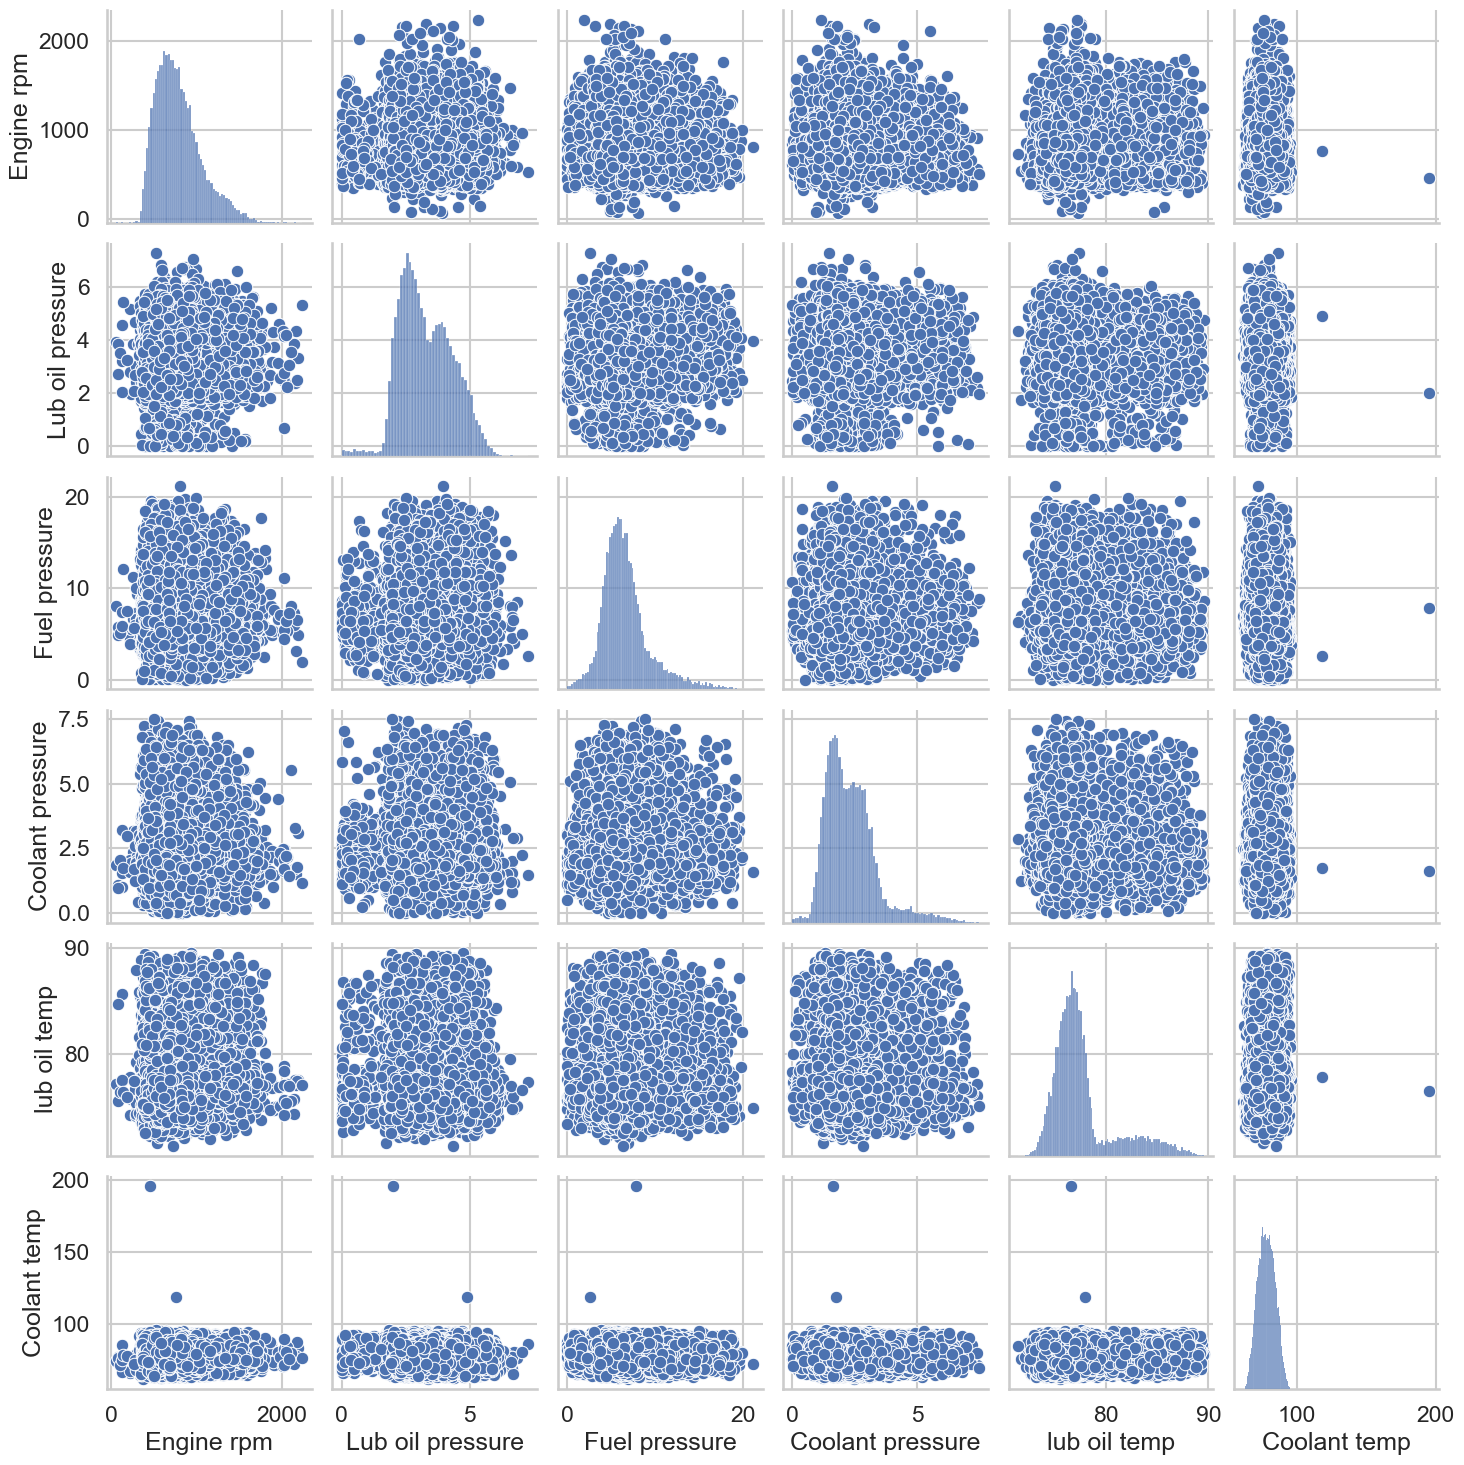

In [65]:
# Inpecting relationships and corrolations between variables

sns.pairplot(df)
print('Pair Plot for the Complete Dataframe')
plt.show()

The scatter plots do not reveal anys strong relationships.

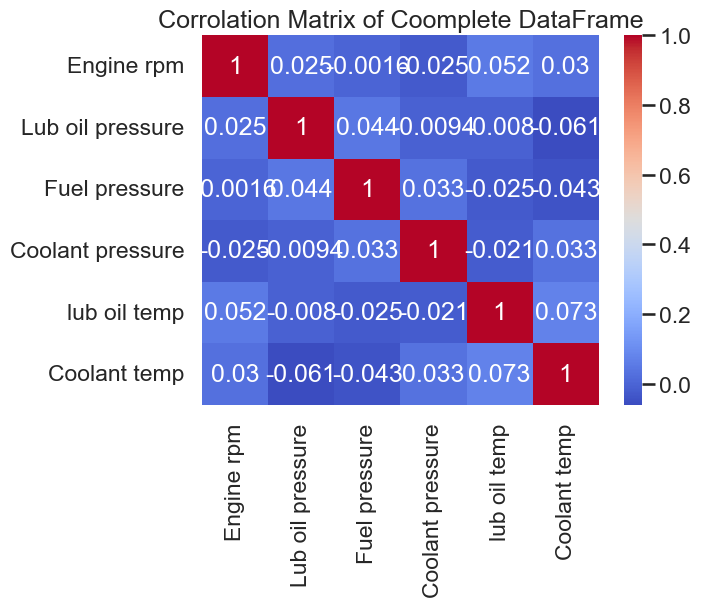

In [66]:
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('Corrolation Matrix of Coomplete DataFrame')
plt.show()

The corrolation matrix additionally indicates no strong corrolation between variables.

Pair Plot of the Z > 3 DataFrame


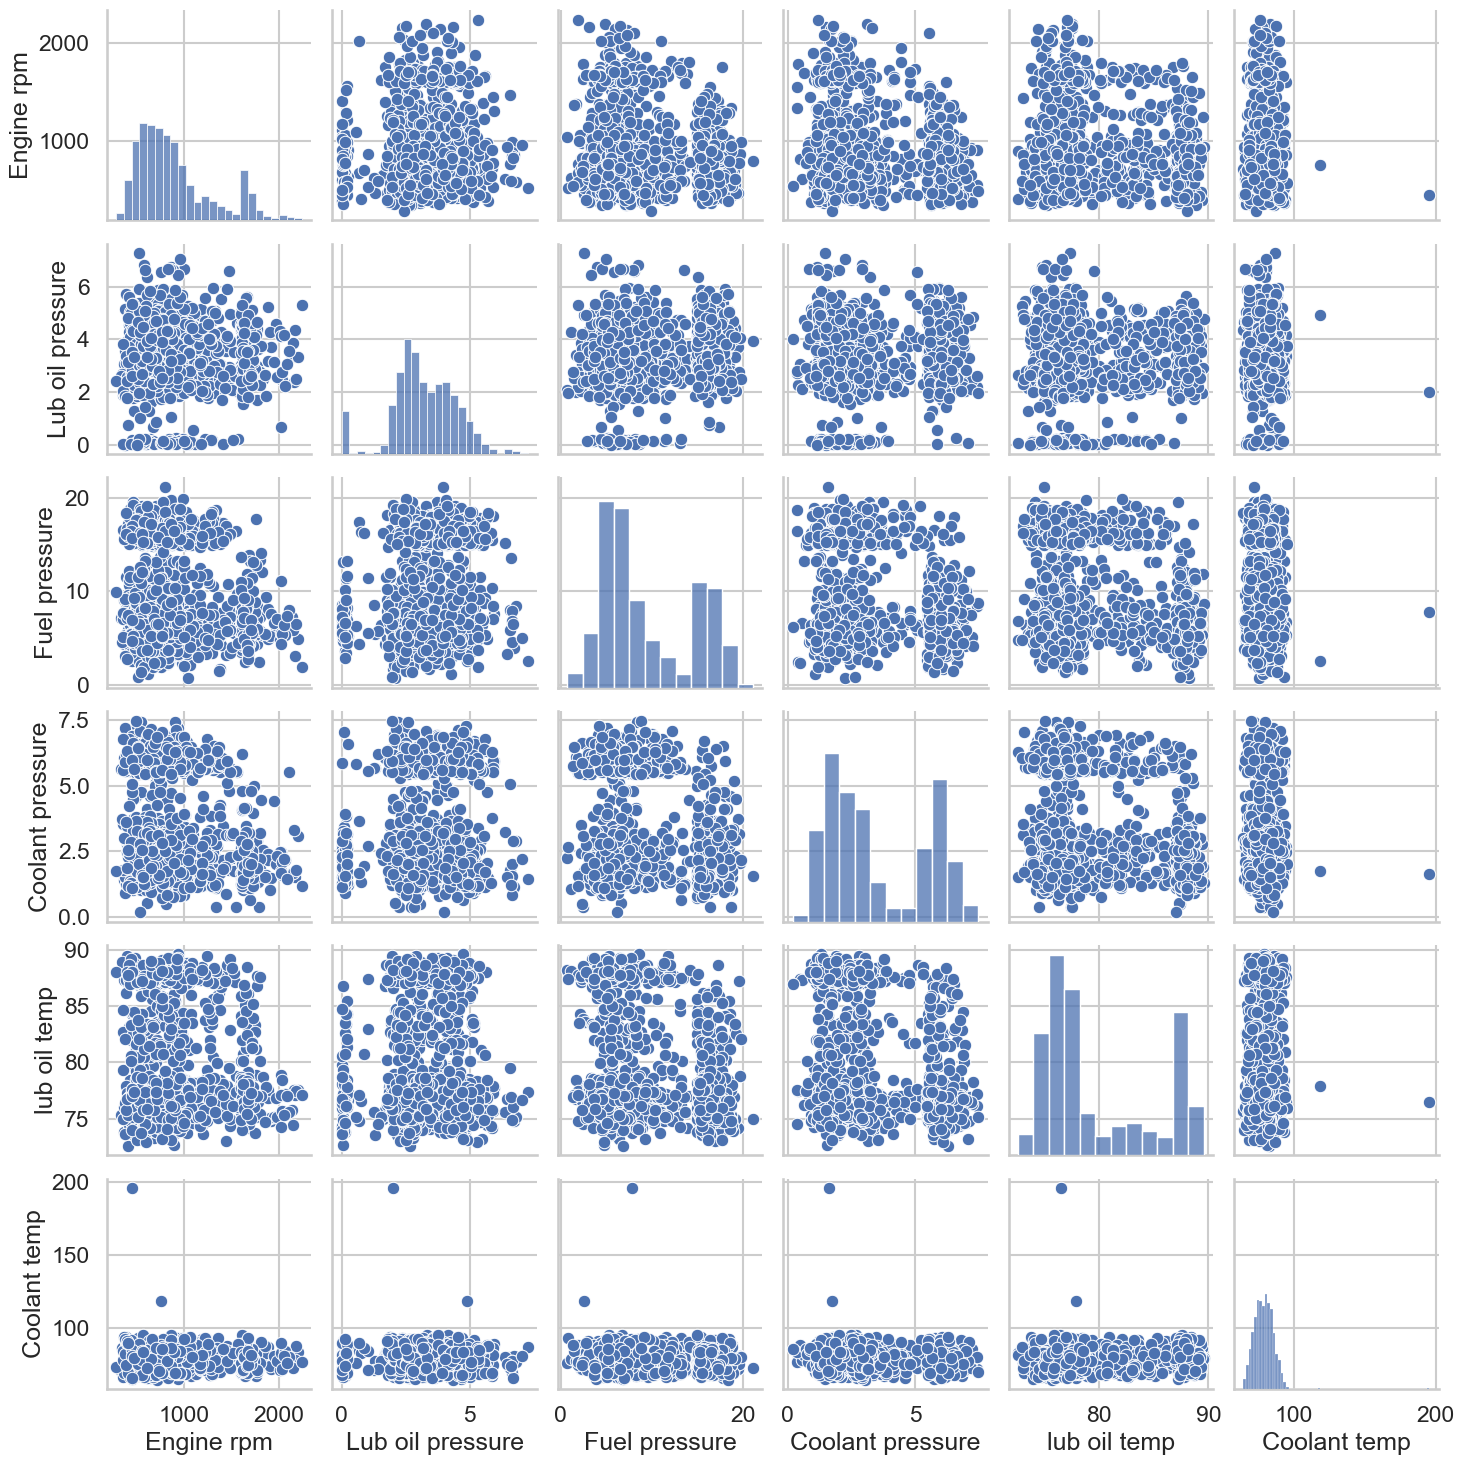

In [67]:
# Investigating relationships between outliers

sns.pairplot(df_z_out)
print('Pair Plot of the Z > 3 DataFrame')
plt.show()

From the pair plot we can see a little structure taking form between variables when looking at the z>3 values.

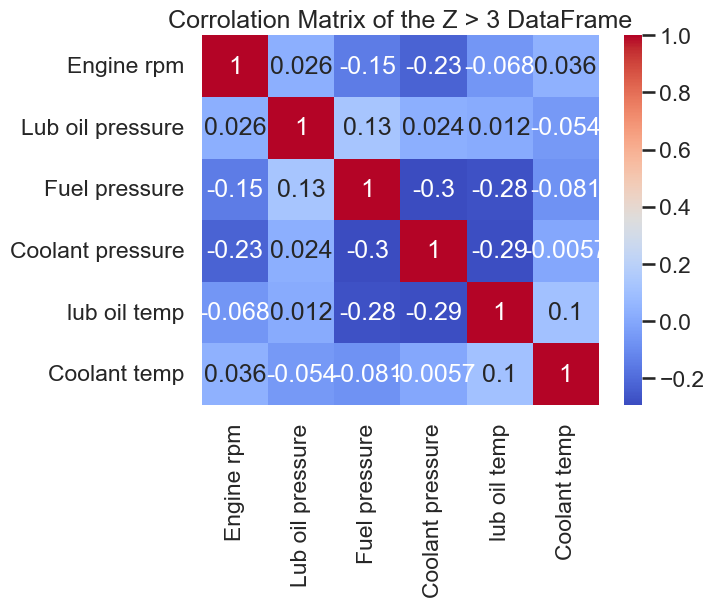

In [68]:
corr_out = df_z_out.corr()
sns.heatmap(corr_out, cmap="coolwarm", annot=True)
plt.title('Corrolation Matrix of the Z > 3 DataFrame')
plt.show()


The corrolation matrix of z>3 observations indicates some relevent corrolation between variables, noteabley 
rpm with coolant pressure
fuel pressure with coolant pressure
fuel pressure with oil temp
coolant pressure with oil temp

all of which are inversely corrolated.

Pair Plot of the Z < 3 DataFrame


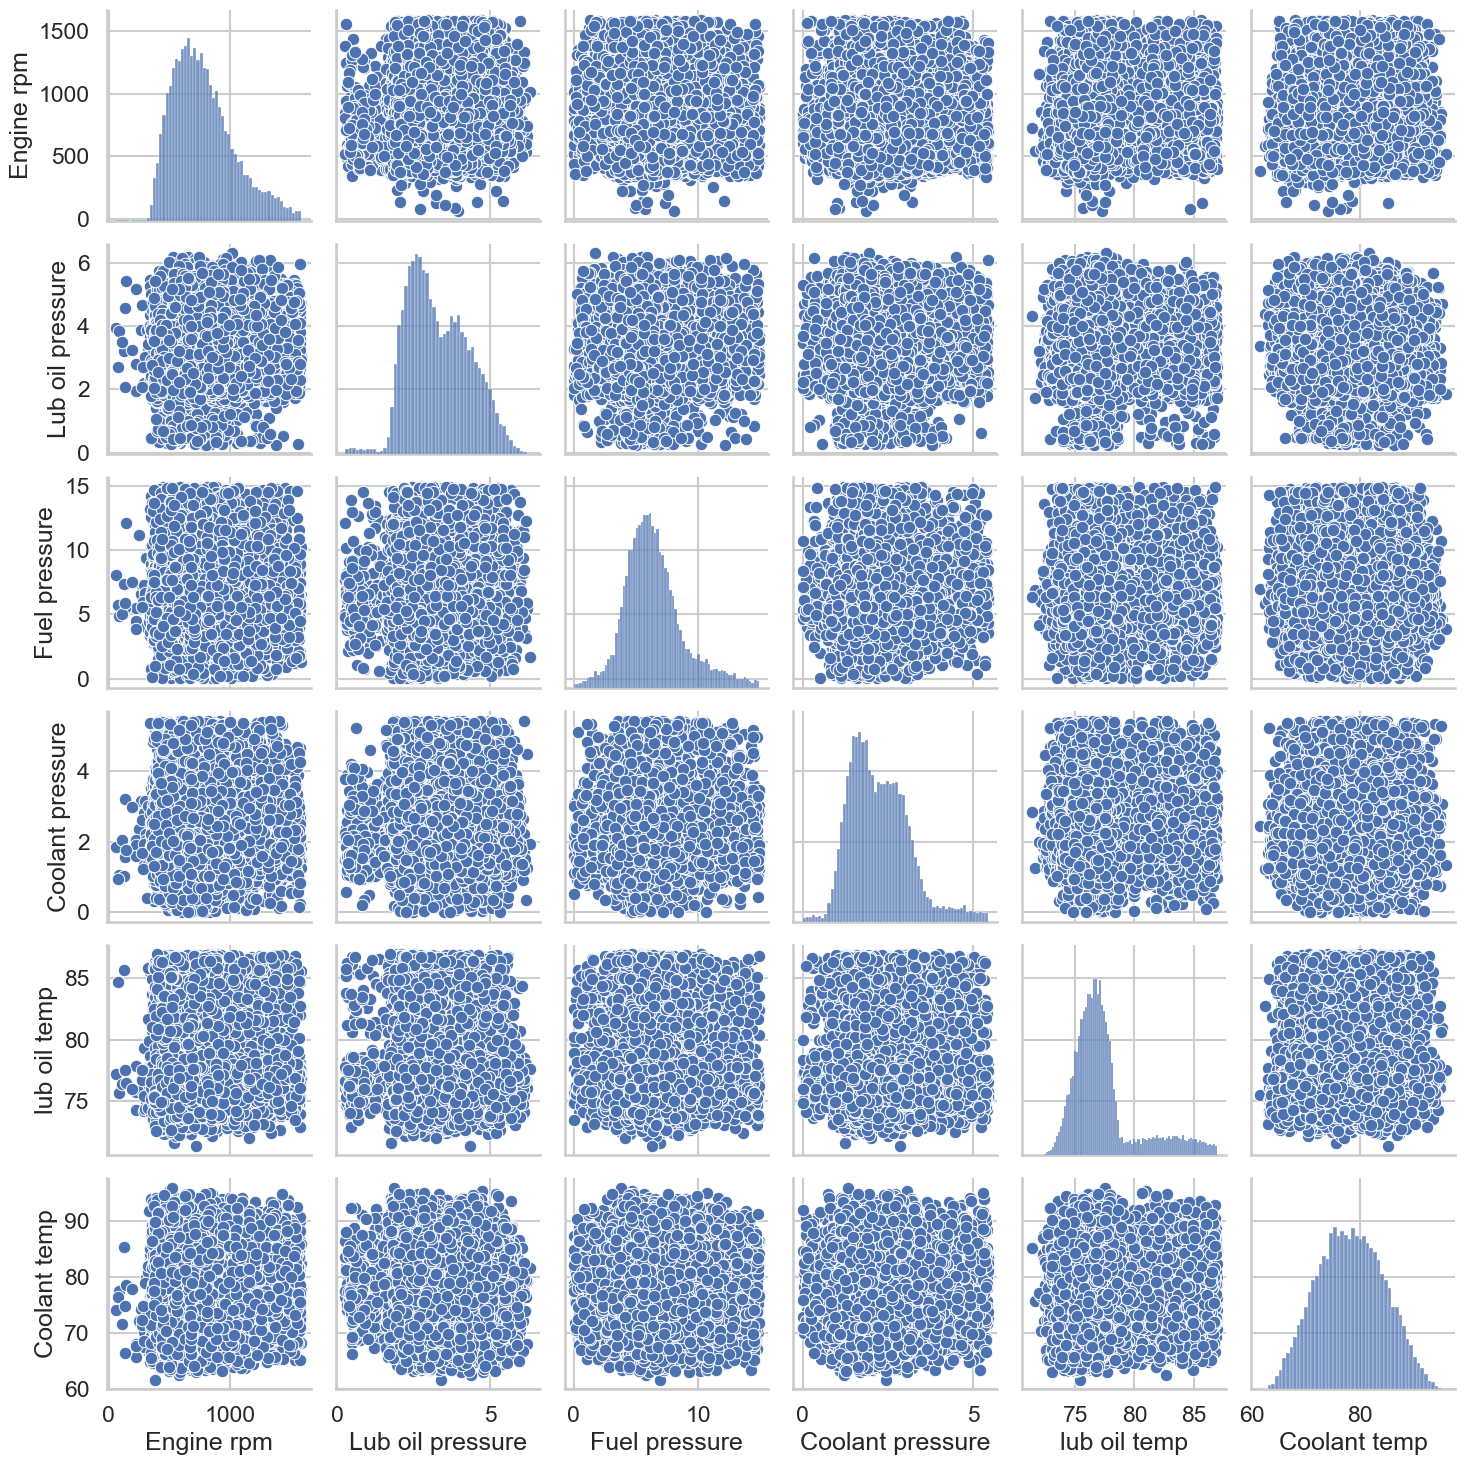

In [69]:
sns.pairplot(df_z_in)
print('Pair Plot of the Z < 3 DataFrame')
plt.show()

Examination of the values within 3 standard devation, we see the distributions tending closer to a normal distribution.

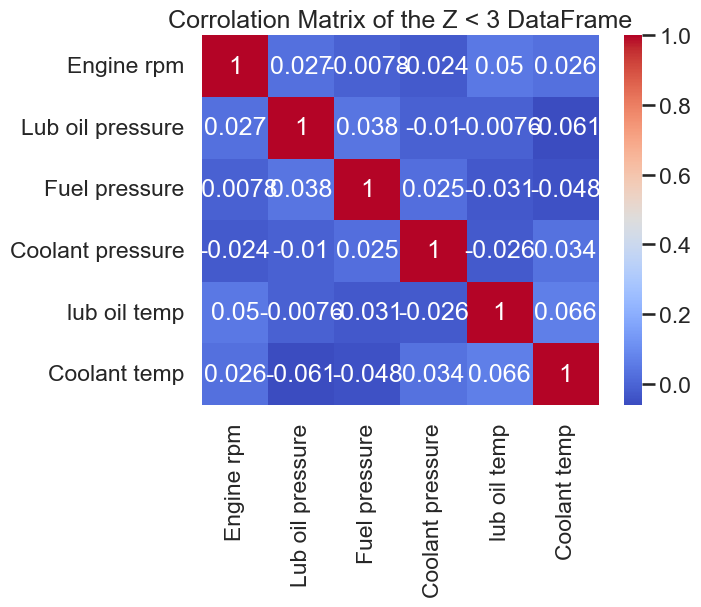

In [70]:
corr_in = df_z_in.corr()
sns.heatmap(corr_in, cmap='coolwarm', annot=True)
plt.title('Corrolation Matrix of the Z < 3 DataFrame')
plt.show()

Now to tidy up some of the variable names and consider some feature creation/selection

In [71]:
# Renaming columns for robust ML processing
df = df.rename(columns={
    "Engine rpm": "engine_rpm",
    "Lub oil pressure": "oil_pressure",
    "Fuel pressure": "fuel_pressure",
    "Coolant pressure": "coolant_pressure",
    "lub oil temp": "oil_temp",
    "Coolant temp": "coolant_temp"
})

In [72]:
# Interquantile range

df = df.copy()

# Filter 5 percent of the tails in any two columns

# Create a dataframe to track extreme values in each row
extreme_count = pd.DataFrame(0, index=df.index, columns=['count'])

# Loop through columns and score each row 
for col in df.columns:
  p025, p975 = df[col].quantile([0.025,0.975])
  df_inner_95 = df[df[col].between(p025,p975)]
  is_extreme = ~df_inner_95[col].between(p025,p975)
  extreme_count['count'] += is_extreme.astype(int)

# Keep rows with fewer than 2 extreme values
df_inner_95 = df_inner_95[extreme_count < 2]

(df_inner_95.shape)
print(f'{100 * (1 - df_inner_95.shape[0]/rows_number)}%')

5.006398771435883%


In [73]:
# Filter using inter quartile range method

# Create a dataframe to track extreme values in each row
df_iqr = df.copy()
df_iqr['count'] = 0

# Loop through each column and score each row
for col in df.columns:
  # Calculate the upper and lower limits.
  q1, q3 = df_iqr[col].quantile([0.25,0.75])
  iqr = q3 - q1
  lower = q1-1.5*iqr
  upper = q3+1.5*iqr
  # Create boolian mask and apply
  mask_outside = ~df_iqr[col].between(lower, upper)
  df_iqr.loc[mask_outside, 'count'] = df_iqr.loc[mask_outside, 'count'] + 1

# IQR results, number of outliers for given boundry
iqr_results = pd.DataFrame(columns=['outlier_boundry', 'outlier_count', 'percentage_of_data'])
for n in range(len(df.columns)):
  mask_outliers = df_iqr['count'] >= n
  outliers = df_iqr.loc[mask_outliers].shape[0]
  perc = 100*outliers/rows_number
  iqr_results.loc[n] = [n, outliers, perc]

iqr_results


,outlier_boundry,outlier_count,percentage_of_data
0,0.0,19535.0,100.000000
1,1.0,4636.0,23.731764
2,2.0,422.0,2.160225
3,3.0,11.0,0.056309
4,4.0,0.0,0.000000
5,5.0,0.0,0.000000


We use statistical methods to effectively remove values from the outer quantiles of data. 
The IQR method applyied allows us to filter outliers based on the number of outliers in a given row.
With 2 as the boundy, we filter 2.16% of data.

**Feature Eningeering**

Basic feature engineering, taking into account the physical laws describting relationships between temperature, pressure and viscosity we can create new features by comparing rates of change beetween variables.

In [74]:
# Feature engineering

# Create a copy of the dataframe
df_feature = df.copy()

# Create constants
alpha = 0.04                    #Viscocity constant
epsilon = 1e-6                  #Small number to prevent infinities
T_mean = df['oil_temp'].mean()  #Mean of the oil temperature

# Create dictionary of interactions
interaction_dict = {
  'P_oil/rpm': df["oil_pressure"]/(df["engine_rpm"] + epsilon),
  'P_fuel/rpm': df['fuel_pressure']/(df["engine_rpm"] + epsilon),
  'P_cool/rpm': df['coolant_pressure']/(df["engine_rpm"] + epsilon),
  'T_oil/rpm': df['oil_temp']/(df["engine_rpm"] + epsilon),
  'T_cool/rpm': df['coolant_temp']/(df["engine_rpm"] + epsilon),
  'P_oil/T_oil': df['oil_pressure']/(df['oil_temp'] + epsilon),
  'P_cool/T_cool': df['coolant_pressure']/(df['coolant_temp'] + epsilon),
  'P_oil/P_cool': df['oil_pressure']/(df['coolant_pressure'] + epsilon),
  'T_oil/T_cool': df['oil_temp']/(df['coolant_temp'] + epsilon),
  'Visc_P_oil': df['oil_pressure'] * np.exp(alpha * (df['oil_temp'] - T_mean))
}

for key, val in interaction_dict.items():
    df_feature[key] = val
df_feature.head()

,engine_rpm,oil_pressure,fuel_pressure,coolant_pressure,oil_temp,coolant_temp,P_oil/rpm,P_fuel/rpm,P_cool/rpm,T_oil/rpm,T_cool/rpm,P_oil/T_oil,P_cool/T_cool,P_oil/P_cool,T_oil/T_cool,Visc_P_oil
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0.003507,0.006770,0.004177,0.111836,0.102470,0.031357,0.040767,0.839477,1.091405,2.264029
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0.009036,0.010619,0.009467,0.121029,0.123814,0.074661,0.076461,0.954493,0.977510,4.580819
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0.005219,0.005594,0.002551,0.133875,0.119612,0.038986,0.021329,2.045758,1.119244,5.215595
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0.002797,0.009507,0.002189,0.103687,0.109996,0.026972,0.019902,1.277486,0.942648,2.096182
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0.005234,0.008811,0.004771,0.111282,0.099339,0.047034,0.048030,1.097010,1.120220,3.212159


Repeating the statistical approach after basic feature engineering our optimum decision boundy increases from 2 to 3, filtering 4.49%

**Feature Discovery**

Let us explore further feature engineering techniques. Considering the system is a ship's engine and the dataset from sensors within parts of the engine system, one would reasonably expect the sesors to be related by physical laws. 

We can employ a model to learn the governing reltionships between variables. We can then make a new set of fetures, ressiduals, that are the difference between true values within the dataset and predicted values based on the discovered equations. The ressiduals can than be used to detect outliers.

We will look for relationships of the following form:


- **$oil_{temp} \propto f(engine_{rpm}, coolant_{pressure})$**
- **$coolant_{temp} \propto f(engine_{rpm}, coolant_{pressure})$**
- **$oil_{pressure} \propto f(oil_{temp})$**
- **$fuel_{pressure} \propto f(engine_{rpm})$**


In [75]:
# Functions to discover
function_dict = {
  'oil_temp' : ['engine_rpm', 'coolant_temp', 'coolant_pressure'],
  'coolant_temp' : ['engine_rpm', 'coolant_pressure', 'oil_temp'],
  'oil_pressure' : ['engine_rpm', 'oil_temp'],
  'fuel_pressure' : ['engine_rpm']
}
functions_found_dict = {}

In [76]:
# Train on the central distribution of data, and only on origional variables
df_core = df.copy()

for col in ['engine_rpm', 'oil_pressure', 'fuel_pressure', 'coolant_pressure', 'oil_temp', 'coolant_temp']:
  q1, q3 = df_core[col].quantile([0.05,0.95])
  df_core = df_core[df_core[col].between(q1, q3)]

In [77]:
EPS = 1e-9

def safe_log(x, eps=EPS):
    # physically: log only makes sense for positive values
    return np.log(np.maximum(x, eps))

def safe_sqrt(x):
    # physically: sqrt only makes sense for non-negative
    return np.sqrt(np.maximum(x, 0.0))

def safe_exp(x, clip=(-20.0, 20.0)):
    # prevent overflow
    x = np.clip(x, clip[0], clip[1])
    return np.exp(x)

def safe_div(a, b, eps=EPS):
    # avoid divide-by-zero and huge spikes
    return a / (b + eps * np.sign(b + eps))

In [78]:
_ALLOWED_FUNCS = {
    "log": safe_log,
    "sqrt": safe_sqrt,
    "exp": safe_exp,
    "abs": np.abs,
    "clip": np.clip,
    "maximum": np.maximum,
    "minimum": np.minimum,
}

In [79]:
from pysr import PySRRegressor

def symbreg(
    df,
    target: str,
    variables: list[str],
    unary_operators: list[str],
    *,
    niterations: int = 1500,
    populations: int = 12,
    population_size: int = 48,
    maxsize: int = 12,
    procs: int = 1,
):
    """
    Fit a symbolic regressor to predict `target` from `variables`.

    IMPORTANT: x0, x1, ... correspond to the column order of `variables`.
    """
    X = df[variables].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float)

    model = PySRRegressor(
        procs=procs,
        niterations=niterations,
        populations=populations,
        population_size=population_size,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=unary_operators,
        loss="loss(x, y) = (x - y)^2",
        maxsize=maxsize,
        verbosity=1,
        batching=True,
        batch_size=50,
    )

    model.fit(X, y)
    print(f"{target} found as {model.sympy()}")
    return model

In [80]:
# For stability of training
import os
os.environ["JULIA_NUM_THREADS"] = "1"

In [81]:
functions_found_dict = {}

for target, variables in function_dict.items():
    unary_ops = ["log", "sqrt"]
    if target == "oil_pressure":
        unary_ops = ["exp", "log", "sqrt"]

    model = symbreg(df_core, target, variables, unary_ops)
    functions_found_dict[target] = model

/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.000e+04
Progress: 1812 / 18000 total iterations (10.067%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.607e+00  0.000e+00  y = 77.366
4           5.598e+00  5.285e-04  y = log(x₁) + 72.995
5           5.597e+00  1.959e-04  y = (x₀ / 1615.5) + 76.919
7           5.589e+00  7.258e-04  y = log(sqrt(x₀) * x₁) + 69.682
8           5.588e+00  1.973e-05  y = (log(sqrt(x₀)) + log(x₁)) + 69.686
9           5.588e+00  1.776e-05  y = log(x₁ * (sqrt(x₀) - -0.16412)) + 69.682
10          5.588e+00  1.311e-05  y = 69.682 + log(sqrt(x₀ + sqrt(x₁)) * x₁)
11          5.588e+00  4.107e-05  y = 69.777 + log(x₁ * (sqrt(x₀) + (0.034092 - x₂)))
12          5.588e+00  1.967e-05  y = log(sqrt(sqrt(x₀)) * (x₁ - (x₂ + -1.7943))) + 71.357
────────────────────────────

[ Info: Final population:
[ Info: Results saved to:
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


  - outputs/20260213_163940_3rNUh7/hall_of_fame.csv

Expressions evaluated per second: 3.140e+04
Progress: 2545 / 18000 total iterations (14.139%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.585e+01  0.000e+00  y = 78.393
4           2.581e+01  5.224e-04  y = sqrt(x₂) + 69.598
6           2.581e+01  8.858e-05  y = sqrt(x₂ * 2.9865) + 63.245
7           2.581e+01  6.086e-05  y = sqrt(x₂ + sqrt(x₀)) + 68.147
8           2.580e+01  2.457e-04  y = sqrt(x₂) + (log(sqrt(x₀)) + 66.307)
10          2.579e+01  1.735e-04  y = log(sqrt(x₀ * x₁)) + (sqrt(x₂) + 65.943)
12          2.579e+01  1.958e-05  y = log(sqrt(x₁ * x₀)) + (sqrt(x₂ - 0.71862) + 65.943)
───────────────────────────────────────────────────────────────────────────────────────────────────
══════════════════════════════════

[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


...

oil_pressure found as -0.011209561*x1/sqrt(log(x0)) + 3.6244302
  - outputs/20260213_164053_co7PTo/hall_of_fame.csv

Expressions evaluated per second: 2.000e+04
Progress: 1528 / 18000 total iterations (8.489%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.674e+00  0.000e+00  y = 6.4771
5           3.674e+00  6.825e-06  y = sqrt(log(x₀) + 35.314)
6           3.674e+00  1.377e-05  y = sqrt(log(sqrt(x₀)) + 38.67)
8           3.674e+00  3.576e-06  y = sqrt(sqrt(sqrt(x₀ * 0.15397)) + 38.67)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 2.390e+04

[ Info: Started!


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.674e+00  0.000e+00  y = 6.4771
5           3.674e+00  6.899e-06  y = sqrt(log(x₀) + 35.348)
6           3.674e+00  1.663e-05  y = (log(x₀) + 123.31) * 0.049856
7           3.674e+00  5.782e-06  y = (sqrt(sqrt(x₀)) + 148.35) * 0.042179
8           3.674e+00  5.960e-07  y = sqrt(sqrt(sqrt(x₀)) + 77.936) * 0.71017
10          3.674e+00  2.384e-07  y = sqrt(sqrt(sqrt(x₀) + 4.0863) + 73.85) * 0.72665
11          3.674e+00  4.590e-06  y = (35.348 / x₀) + sqrt(log(x₀ * 0.48793) + 35.348)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 2.170e+04
Progress: 17778 / 18000 total iterations (98.767%)
════════

[ Info: Final population:
[ Info: Results saved to:


fuel_pressure found as 0.0011165774*x0 - 0.842673810742878*log(x0) + 11.1875305
  - outputs/20260213_164129_PuhTnR/hall_of_fame.csv


In [82]:
# Make predictions using the discovered equations, calculate ressiduals, add ressidual as new feature
df_fe = df_feature.copy()
predications_dict = {}
error_dict = {}

for (target, variables), (target_name, model) in zip(function_dict.items(), functions_found_dict.items()):
  X = df_fe[variables].values
  Y = df_fe[target].values
  y_pred = model.predict(X)
  predications_dict[target_name] = y_pred
  df_fe[f'SR_residual_{target_name}'] = Y - y_pred
  df_fe[f'SR_abs_resid_{target_name}'] = np.abs(df_fe[f'SR_residual_{target_name}'])

In [83]:
df_fe.head()

,engine_rpm,oil_pressure,fuel_pressure,coolant_pressure,oil_temp,coolant_temp,P_oil/rpm,P_fuel/rpm,P_cool/rpm,T_oil/rpm,...,T_oil/T_cool,Visc_P_oil,SR_residual_oil_temp,SR_abs_resid_oil_temp,SR_residual_coolant_temp,SR_abs_resid_coolant_temp,SR_residual_oil_pressure,SR_abs_resid_oil_pressure,SR_residual_fuel_pressure,SR_abs_resid_fuel_pressure
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0.003507,0.006770,0.004177,0.111836,...,1.091405,2.264029,-0.934889,0.934889,-8.447139,8.447139,-0.898067,0.898067,-1.833369,1.833369
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0.009036,0.010619,0.009467,0.121029,...,0.977510,4.580819,-3.994131,3.994131,-3.248051,3.248051,2.166762,2.166762,-0.041181,0.041181
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0.005219,0.005594,0.002551,0.133875,...,1.119244,5.215595,10.781664,10.781664,-0.279157,0.279157,0.197434,0.197434,-2.773059,2.773059
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0.002797,0.009507,0.002189,0.103687,...,0.942648,2.096182,0.242887,0.242887,3.975777,3.975777,-1.191392,1.191392,0.674518,0.674518
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0.005234,0.008811,0.004771,0.111282,...,1.120220,3.212159,-1.936667,1.936667,-11.118432,11.118432,0.244138,0.244138,-0.494839,0.494839


Now let us create ressiduals for the feature engineered set, as to make a fair comparison to the symbolic regression set. The SR is allowing for non-linear relationships, so to make it a fair comparson let us use random forest regression.

In [84]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

In [85]:

def add_ratio_residuals_rf_oof(
    df: pd.DataFrame,
    target_cols=("oil_temp", "coolant_temp", "oil_pressure", "fuel_pressure"),
    feature_cols=None,
    rf_params=None,
    n_splits=5,
    prefix="RATIO_RF_OOF",
):
    """
    Adds residual features using out-of-fold predictions to avoid overly
    optimistic residuals.
    """
    df_out = df.copy()

    if feature_cols is None:
        feature_cols = [c for c in df_out.columns if c not in target_cols]

    if rf_params is None:
        rf_params = dict(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        )

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    models = {}
    for target in target_cols:
        if target not in df_out.columns:
            raise KeyError(f"Target column '{target}' missing from dataframe.")

        X = df_out[feature_cols].to_numpy()
        y = df_out[target].to_numpy()

        y_pred_oof = np.empty_like(y, dtype=float)

        # Train a model per fold to generate OOF predictions
        for train_idx, val_idx in kf.split(X):
            model = RandomForestRegressor(**rf_params)
            model.fit(X[train_idx], y[train_idx])
            y_pred_oof[val_idx] = model.predict(X[val_idx])

        resid = y - y_pred_oof
        df_out[f"{prefix}_residual_{target}"] = resid
        df_out[f"{prefix}_abs_resid_{target}"] = np.abs(resid)

        # Fit model on all data
        final_model = RandomForestRegressor(**rf_params)
        final_model.fit(X, y)
        models[target] = final_model

    return df_out, models, feature_cols

In [86]:
ratio_cols = [
    "P_oil/rpm","P_fuel/rpm","P_cool/rpm",
    "T_oil/rpm","T_cool/rpm",
    "P_oil/T_oil","P_cool/T_cool",
    "P_oil/P_cool","T_oil/T_cool",
    "Visc_P_oil"
]

df_feature, rf_models, used_cols = add_ratio_residuals_rf_oof(
    df_feature,
    target_cols=("oil_temp","coolant_temp","oil_pressure","fuel_pressure"),
    feature_cols=ratio_cols,
    n_splits=5
)

Now let us reapply statistical filtering with the new features included.

In [87]:
# IQR function

def IQR(df_list=list):
  
  # List of processed df's
  df_iqr_list = []
  iqr_results_list = []
  
  for df in df_list:
    # Create a dataframe to track extreme values in each row
    df_iqr = df.copy()
    df_iqr['count'] = 0

    # Loop through each column and score each row
    for col in df_iqr.columns:
      # Calculate the upper and lower limits.
      q1, q3 = df_iqr[col].quantile([0.25,0.75])
      iqr = q3 - q1
      lower = q1-1.5*iqr
      upper = q3+1.5*iqr
      # Create boolian mask and apply
      mask_outside = ~df_iqr[col].between(lower, upper)
      df_iqr.loc[mask_outside, 'count'] = df_iqr.loc[mask_outside, 'count'] + 1

    # IQR results, number of outliers for given boundry
    iqr_results = pd.DataFrame(columns=['outlier_boundry', 'outlier_count', 'percentage_of_data'])
    for n in range(len(df_fe.columns)):
      mask_outliers = df_iqr['count'] >= n
      outliers = df_iqr.loc[mask_outliers].shape[0]
      perc = 100*outliers/rows_number
      iqr_results.loc[n] = [n, outliers, perc]
    
    df_iqr_list.append(df_iqr)
    iqr_results_list.append(iqr_results)
  return df_iqr_list, iqr_results_list
      
df_iqr_list, iqr_results_list = IQR([df, df_fe, df_feature])



In [88]:
iqr_results_list[0].iloc[:6]


,outlier_boundry,outlier_count,percentage_of_data
0,0.0,19535.0,100.000000
1,1.0,4636.0,23.731764
2,2.0,4636.0,23.731764
3,3.0,422.0,2.160225
4,4.0,11.0,0.056309
5,5.0,0.0,0.000000


In [89]:
iqr_results_list[1].iloc[:8]

,outlier_boundry,outlier_count,percentage_of_data
0,0.0,19535.0,100.000000
1,1.0,6457.0,33.053494
2,2.0,4629.0,23.695930
3,3.0,3474.0,17.783466
4,4.0,3474.0,17.783466
5,5.0,1317.0,6.741746
6,6.0,545.0,2.789864
7,7.0,265.0,1.356540


In [90]:
iqr_results_list[2].iloc[:10]

,outlier_boundry,outlier_count,percentage_of_data
0,0.0,19535.0,100.000000
1,1.0,8396.0,42.979268
2,2.0,5899.0,30.197082
3,3.0,3972.0,20.332736
4,4.0,2622.0,13.422063
5,5.0,1734.0,8.876376
6,6.0,1194.0,6.112106
7,7.0,1194.0,6.112106
8,8.0,708.0,3.624264
9,9.0,403.0,2.062964


With full feature engineering regime applied, the boundry increases to 10, filtering 2.1% of data.

Let us now apply some machine learning techniques to each feature set.

In [91]:
df = df.copy()        # Origional feature set
df_feature = df_feature.copy()  # Ratio engineered-ressidual set
df_symbolic = df_fe.copy()  # Ratio and Ressidual set


In [92]:
print(f'{df.head()}\n')

   engine_rpm  oil_pressure  fuel_pressure  coolant_pressure   oil_temp  \
0         682      2.391656       4.617196          2.848982  76.272417   
1         605      5.466877       6.424361          5.727520  73.222679   
2         658      3.434232       3.680896          1.678708  88.089916   
3         749      2.094656       7.120927          1.639670  77.661625   
4         676      3.538228       5.956472          3.225336  75.226352   

   coolant_temp  
0     69.884609  
1     74.907314  
2     78.704806  
3     82.386700  
4     67.153220  



In [93]:
print(f'{df_feature.head()}\n')

   engine_rpm  oil_pressure  fuel_pressure  coolant_pressure   oil_temp  \
0         682      2.391656       4.617196          2.848982  76.272417   
1         605      5.466877       6.424361          5.727520  73.222679   
2         658      3.434232       3.680896          1.678708  88.089916   
3         749      2.094656       7.120927          1.639670  77.661625   
4         676      3.538228       5.956472          3.225336  75.226352   

   coolant_temp  P_oil/rpm  P_fuel/rpm  P_cool/rpm  T_oil/rpm  ...  \
0     69.884609   0.003507    0.006770    0.004177   0.111836  ...   
1     74.907314   0.009036    0.010619    0.009467   0.121029  ...   
2     78.704806   0.005219    0.005594    0.002551   0.133875  ...   
3     82.386700   0.002797    0.009507    0.002189   0.103687  ...   
4     67.153220   0.005234    0.008811    0.004771   0.111282  ...   

   T_oil/T_cool  Visc_P_oil  RATIO_RF_OOF_residual_oil_temp  \
0      1.091405    2.264029                        0.030347   
1 

In [94]:
print(f'{df_symbolic.head()}\n')

   engine_rpm  oil_pressure  fuel_pressure  coolant_pressure   oil_temp  \
0         682      2.391656       4.617196          2.848982  76.272417   
1         605      5.466877       6.424361          5.727520  73.222679   
2         658      3.434232       3.680896          1.678708  88.089916   
3         749      2.094656       7.120927          1.639670  77.661625   
4         676      3.538228       5.956472          3.225336  75.226352   

   coolant_temp  P_oil/rpm  P_fuel/rpm  P_cool/rpm  T_oil/rpm  ...  \
0     69.884609   0.003507    0.006770    0.004177   0.111836  ...   
1     74.907314   0.009036    0.010619    0.009467   0.121029  ...   
2     78.704806   0.005219    0.005594    0.002551   0.133875  ...   
3     82.386700   0.002797    0.009507    0.002189   0.103687  ...   
4     67.153220   0.005234    0.008811    0.004771   0.111282  ...   

   T_oil/T_cool  Visc_P_oil  SR_residual_oil_temp  SR_abs_resid_oil_temp  \
0      1.091405    2.264029             -0.934889   

**Feature Selection**

In [95]:
# VIF analysis of dataframe
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

vif_df = pd.DataFrame()
vif_df['variables'] = df.columns
vif_df['VIF'] = [vif(df.values, i) for i in range(len(df.columns))]
print(vif_df.sort_values(by='VIF', ascending=True))

          variables         VIF
3  coolant_pressure    6.056369
2     fuel_pressure    6.754031
0        engine_rpm    9.766473
1      oil_pressure   11.298999
5      coolant_temp  137.068210
4          oil_temp  157.311236


Although there is large coliniarity within the last two variables, lets keep the origional feature set as is for comparison.

In [96]:
# VIF analysis of ratios dataframe
vif_df_feature = pd.DataFrame()
vif_df_feature['variables'] = df_feature.columns
vif_df_feature['VIF'] = [vif(df_feature.values, i) for i in range(len(df_feature.columns))]
print(vif_df_feature.sort_values(by='VIF', ascending=True))

                               variables            VIF
13                          P_oil/P_cool       1.020479
20    RATIO_RF_OOF_residual_oil_pressure       1.297966
16        RATIO_RF_OOF_residual_oil_temp       1.709565
21   RATIO_RF_OOF_abs_resid_oil_pressure       1.843943
17       RATIO_RF_OOF_abs_resid_oil_temp       2.066871
18    RATIO_RF_OOF_residual_coolant_temp       2.536150
22   RATIO_RF_OOF_residual_fuel_pressure       2.754837
19   RATIO_RF_OOF_abs_resid_coolant_temp       3.357855
23  RATIO_RF_OOF_abs_resid_fuel_pressure       3.801572
0                             engine_rpm      45.992308
8                             P_cool/rpm      59.196380
7                             P_fuel/rpm      69.013937
2                          fuel_pressure      70.454005
6                              P_oil/rpm     108.707948
12                         P_cool/T_cool     984.103008
3                       coolant_pressure    1013.162384
10                            T_cool/rpm    1370

There is a huge amount of covariance with this feature set, as to be expected with features and prediction generated from other features. This actualy acts as a confirmation for the feature creation and we can safely drop the origional features.

In [97]:
df_feature_reduced = df_feature.copy().drop(['engine_rpm', 'oil_pressure', 'fuel_pressure', 'coolant_pressure', 'oil_temp', 'coolant_temp', 'P_oil/rpm', 'P_fuel/rpm', 'P_cool/rpm', 'T_oil/rpm', 'T_cool/rpm', 'P_oil/T_oil', 'P_cool/T_cool', 'P_oil/P_cool', 'T_oil/T_cool', 'Visc_P_oil',], axis=1)
df_feature_reduced.head()

,RATIO_RF_OOF_residual_oil_temp,RATIO_RF_OOF_abs_resid_oil_temp,RATIO_RF_OOF_residual_coolant_temp,RATIO_RF_OOF_abs_resid_coolant_temp,RATIO_RF_OOF_residual_oil_pressure,RATIO_RF_OOF_abs_resid_oil_pressure,RATIO_RF_OOF_residual_fuel_pressure,RATIO_RF_OOF_abs_resid_fuel_pressure
0,0.030347,0.030347,-0.301903,0.301903,0.000621,0.000621,-0.111570,0.111570
1,-0.688358,0.688358,-1.757620,1.757620,-0.077307,0.077307,-0.341985,0.341985
2,0.535690,0.535690,2.022944,2.022944,0.020789,0.020789,0.197088,0.197088
3,0.005376,0.005376,0.172292,0.172292,-0.001144,0.001144,0.039761,0.039761
4,-0.276038,0.276038,-0.323585,0.323585,0.000101,0.000101,-0.182511,0.182511


In [98]:
# VIF analysis of ratios + ressiduals dataframe
vif_df_symbolic = pd.DataFrame()
vif_df_symbolic['variables'] = df_symbolic.columns
vif_df_symbolic['VIF'] = [vif(df_symbolic.values, i) for i in range(len(df_symbolic.columns))]
print(vif_df_symbolic.sort_values(by='VIF', ascending=True))

                     variables           VIF
13                P_oil/P_cool  1.020576e+00
23  SR_abs_resid_fuel_pressure  2.783737e+00
21   SR_abs_resid_oil_pressure  3.330231e+00
19   SR_abs_resid_coolant_temp  8.818451e+00
17       SR_abs_resid_oil_temp  1.409375e+01
8                   P_cool/rpm  6.217362e+01
7                   P_fuel/rpm  6.949903e+01
6                    P_oil/rpm  1.109600e+02
12               P_cool/T_cool  9.913315e+02
3             coolant_pressure  1.023166e+03
10                  T_cool/rpm  1.601535e+03
9                    T_oil/rpm  2.254790e+03
15                  Visc_P_oil  1.476542e+04
0                   engine_rpm  9.785460e+04
14                T_oil/T_cool  1.016618e+05
11                 P_oil/T_oil  1.875062e+05
22   SR_residual_fuel_pressure  8.801689e+05
16        SR_residual_oil_temp  2.931675e+06
2                fuel_pressure  5.976640e+06
20    SR_residual_oil_pressure  1.406109e+07
18    SR_residual_coolant_temp  1.449038e+07
1         

High amounts of colinearity again due to the feature creation method. keeping the following variables due to low VIF score:

SR_abs_resid_oil_temp        (thermal violation)
SR_abs_resid_coolant_temp    (cooling failure signal)
SR_abs_resid_oil_pressure    (lubrication anomaly)
SR_abs_resid_fuel_pressure   (fuel regulation anomaly)

P_oil/P_cool                 (pressure balance indicator)

and the following two variables based on the initial data exploration (scatter and corrolation plots):

engine_rpm                  (operating regime)
coolant_pressure            (cooling system state)

In [99]:
df_symbolic_reduced = df_symbolic[['engine_rpm', 'coolant_pressure', 'SR_abs_resid_oil_temp', 'SR_abs_resid_coolant_temp', 'SR_abs_resid_oil_pressure', 'SR_abs_resid_fuel_pressure', 'P_oil/P_cool']]

In [100]:
# VIF re-analysis
vif_df_reduced = pd.DataFrame()
vif_df_reduced['variables'] = df_feature_reduced.columns
vif_df_reduced['VIF'] = [vif(df_feature_reduced, i) for i in range(len(df_feature_reduced.columns))]
print(vif_df_reduced.sort_values(by='VIF', ascending=True))

                              variables       VIF
4    RATIO_RF_OOF_residual_oil_pressure  1.269157
6   RATIO_RF_OOF_residual_fuel_pressure  1.326915
7  RATIO_RF_OOF_abs_resid_fuel_pressure  1.540760
0        RATIO_RF_OOF_residual_oil_temp  1.572108
5   RATIO_RF_OOF_abs_resid_oil_pressure  1.609642
1       RATIO_RF_OOF_abs_resid_oil_temp  1.773247
2    RATIO_RF_OOF_residual_coolant_temp  2.241637
3   RATIO_RF_OOF_abs_resid_coolant_temp  2.473804


In [101]:
vif_df_symbolic_reduced = pd.DataFrame()
vif_df_symbolic_reduced['variables'] = df_symbolic_reduced.columns
vif_df_symbolic_reduced['VIF'] = [vif(df_symbolic_reduced, i) for i in range(len(df_symbolic_reduced.columns))]
print(vif_df_symbolic_reduced)

                    variables       VIF
0                  engine_rpm  5.609389
1            coolant_pressure  4.575274
2       SR_abs_resid_oil_temp  1.833895
3   SR_abs_resid_coolant_temp  2.716586
4   SR_abs_resid_oil_pressure  2.872721
5  SR_abs_resid_fuel_pressure  1.968903
6                P_oil/P_cool  1.015030


**Data Scaling and Pre-Processing**

Now with 3 data frames to compare, lets prepare them for training OCSVM and Iso Forest models

In [112]:
# Columns
df_columns = df.columns
print(df_columns)

df_feature_reduced_columns = df_feature_reduced.columns
print(df_feature_reduced_columns)

df_symbolic_reduced_columns = df_symbolic_reduced.columns
print(df_symbolic_reduced_columns)

Index(['engine_rpm', 'oil_pressure', 'fuel_pressure', 'coolant_pressure',
       'oil_temp', 'coolant_temp'],
      dtype='object')
Index(['RATIO_RF_OOF_residual_oil_temp', 'RATIO_RF_OOF_abs_resid_oil_temp',
       'RATIO_RF_OOF_residual_coolant_temp',
       'RATIO_RF_OOF_abs_resid_coolant_temp',
       'RATIO_RF_OOF_residual_oil_pressure',
       'RATIO_RF_OOF_abs_resid_oil_pressure',
       'RATIO_RF_OOF_residual_fuel_pressure',
       'RATIO_RF_OOF_abs_resid_fuel_pressure'],
      dtype='object')
Index(['engine_rpm', 'coolant_pressure', 'SR_abs_resid_oil_temp',
       'SR_abs_resid_coolant_temp', 'SR_abs_resid_oil_pressure',
       'SR_abs_resid_fuel_pressure', 'P_oil/P_cool'],
      dtype='object')


In [113]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df = df.copy()
df_feature_reduced = df_feature_reduced.copy()
df_symbolic_reduced = df_symbolic_reduced.copy()

X = df.values
X_f_r = df_feature_reduced.values
X_sy_r = df_symbolic_reduced.values
X_scaled = scaler.fit_transform(X)
X_f_r_scaled = scaler.fit_transform(X_f_r)
X_sy_r_scaled = scaler.fit_transform(X_sy_r)

# Ceate a library of X related data
X_lib = {
  'X': [X, X_scaled, df_columns], 
  'X_featured': [X_f_r, X_f_r_scaled, df_feature_reduced_columns],
  'X_SR': [X_sy_r, X_sy_r_scaled, df_symbolic_reduced_columns],
}



In [115]:
# Create dictionary of parameters to try with the OCSVM

param_grid_OCSVM = [
    {'kernel': 'rbf', 'gamma': 0.1, 'nu': 0.02},
    {'kernel': 'rbf', 'gamma': 0.2, 'nu': 0.02},
    {'kernel': 'rbf', 'gamma': 0.3, 'nu': 0.02},
    {'kernel': 'rbf', 'gamma': 0.4, 'nu': 0.02},
    {'kernel': 'rbf', 'gamma': 0.5, 'nu': 0.02},
    {'kernel': 'rbf', 'gamma': 0.1, 'nu': 0.02},
    {'kernel': 'rbf', 'gamma': 0.2, 'nu': 0.03},
    {'kernel': 'rbf', 'gamma': 0.3, 'nu': 0.03},
    {'kernel': 'rbf', 'gamma': 0.4, 'nu': 0.03},
    {'kernel': 'rbf', 'gamma': 0.5, 'nu': 0.03},
    {'kernel': 'rbf', 'gamma': 0.1, 'nu': 0.02},
    {'kernel': 'rbf', 'gamma': 0.2, 'nu': 0.04},
    {'kernel': 'rbf', 'gamma': 0.3, 'nu': 0.04},
    {'kernel': 'rbf', 'gamma': 0.4, 'nu': 0.04},
    {'kernel': 'rbf', 'gamma': 0.5, 'nu': 0.04},
    {'kernel': 'rbf', 'gamma': 0.1, 'nu': 0.02},
    {'kernel': 'rbf', 'gamma': 0.2, 'nu': 0.05},
    {'kernel': 'rbf', 'gamma': 0.3, 'nu': 0.05},
    {'kernel': 'rbf', 'gamma': 0.4, 'nu': 0.05},
    {'kernel': 'rbf', 'gamma': 0.5, 'nu': 0.05}
]

In [116]:
# One Class Support Vector Machine
from sklearn.svm import OneClassSVM
from sklearn.base import clone

# Create results library
ocsvm_results = {}

# Unpack the X data library
for key, x in X_lib.items():

    # Create a results list for each run
    ocsvm_results[key] = []
    # Useful x items
    X_data = x[0]
    columns = x[2]

    # Track best
    best_sep = -np.inf
    best_result = None
    
    # Loop through the parameter library
    for param in param_grid_OCSVM:
        
        # Create the model and fit to the scaled data
        model = OneClassSVM(**param)
        model.fit(x[1])

        # Use the model to predict outliers on the scaled data
        # Tracking predictions and scores
        y_pred = model.predict(x[1])
        scores = model.decision_function(x[1])
        
        # Create a dataframe of the scaled data
        df_out = pd.DataFrame(X_data, columns=columns)
        df_out["anomaly"] = y_pred
        df_out["score"] = scores
        
        # Create a dataframe of only anomulus data
        anomalies = df_out[df_out['anomaly'] == -1]
        
        # Create a seperation metric to evaluate each model
        sep = (
            scores[y_pred ==1].mean() - scores[y_pred == -1].mean()
            )/ scores.std()

        # Store result if it has the best separation so far
        if sep > best_sep:
            best_sep = sep
            best_result = {
                "params": param,
                "y_pred": y_pred,
                "scores": scores,
                "df": df_out,
                "anomalies": anomalies,
                "separation": sep
            }
            ocsvm_model = clone(model)
            
        # Display results and evaluation of each model
        print(
            f'[OCSVM] {key} | {param} → '
            f'{anomalies.shape[0]} anomalies '
            f'({anomalies.shape[0] / rows_number:.2%}) '
            f'separation {sep:.2f}'
        )
        
    # Store only the best result for this key
    ocsvm_results[key] = best_result
    print(f"\nBest for {key}: separation = {best_sep:.2f}\n")
        
    

[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.1, 'nu': 0.02} → 392 anomalies (2.01%) separation 2.91
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.2, 'nu': 0.02} → 389 anomalies (1.99%) separation 3.36
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.3, 'nu': 0.02} → 433 anomalies (2.22%) separation 3.03
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.4, 'nu': 0.02} → 486 anomalies (2.49%) separation 2.41
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.5, 'nu': 0.02} → 627 anomalies (3.21%) separation 1.90
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.1, 'nu': 0.02} → 392 anomalies (2.01%) separation 2.91
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.2, 'nu': 0.03} → 590 anomalies (3.02%) separation 3.12
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.3, 'nu': 0.03} → 589 anomalies (3.02%) separation 3.15
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.4, 'nu': 0.03} → 632 anomalies (3.24%) separation 2.69
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0.5, 'nu': 0.03} → 737 anomalies (3.77%) separation 2.12
[OCSVM] X | {'kernel': 'rbf', 'gamma': 0

In [117]:
# Create a library of parameters to try with the isolation forest

param_grid = [
    {'contamination': 0.02, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0},
    {'contamination': 0.03, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0},
    {'contamination': 0.04, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0},
    {'contamination': 0.05, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0},
    {'contamination': 0.02, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0},
    {'contamination': 0.03, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0},
    {'contamination': 0.04, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0},
    {'contamination': 0.05, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0},
]

In [118]:
# Loop to try each parameter set with each X_scaled dataset and store in a results library
from sklearn.ensemble import IsolationForest
from sklearn.base import clone

tree_results = {}

for key, x in X_lib.items():
    X_data = x[0]
    columns = x[2]

    best_sep = -np.inf
    best_result = None

    for param in param_grid:
        iso_forest = IsolationForest(**param, random_state=42)
        iso_forest.fit(X_data)

        y_pred = iso_forest.predict(X_data)
        scores = iso_forest.decision_function(X_data)

        df_out = pd.DataFrame(X_data, columns=columns)
        df_out["anomaly"] = y_pred
        df_out["score"] = scores

        anomalies = df_out[df_out["anomaly"] == -1]
        
        # Separation metric to evaluate each model and feature set
        sep = (
            scores[y_pred == 1].mean() - scores[y_pred == -1].mean()
        ) / scores.std()

        # Store result if it has the best separation so far
        if sep > best_sep:
            best_sep = sep
            best_result = {
                "params": param,
                "y_pred": y_pred,
                "scores": scores,
                "df": df_out,
                "anomalies": anomalies,
                "separation": sep
            }
            tree_model = clone(model)

        print(
            f"[IF] {key} | {param} → "
            f"{anomalies.shape[0]} anomalies "
            f"({anomalies.shape[0] / len(X_data):.2%}) "
            f"separation {sep:.2f}"
        )
    
    # Store only the best result for this key
    tree_results[key] = best_result
    print(f"\nBest for {key}: separation = {best_sep:.2f}\n")

[IF] X | {'contamination': 0.02, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0} → 391 anomalies (2.00%) separation 3.00
[IF] X | {'contamination': 0.03, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0} → 587 anomalies (3.00%) separation 2.82
[IF] X | {'contamination': 0.04, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0} → 782 anomalies (4.00%) separation 2.70
[IF] X | {'contamination': 0.05, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0} → 977 anomalies (5.00%) separation 2.60
[IF] X | {'contamination': 0.02, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0} → 391 anomalies (2.00%) separation 3.10
[IF] X | {'contamination': 0.03, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0} → 587 anomalies (3.00%) separation 2.91
[IF] X | {'contamination': 0.04, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0} → 782 anomalies (4.00%) separation 2.77
[IF] X | {'contamination': 0.05, 'n_estimators': 500, '

In [119]:
import umap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_umap_anomalies(
    X_scaled,
    y_pred=None,
    decision_scores=None,
    n_neighbors=25,
    min_dist=0.10,
    metric='euclidean',
    random_state=42,
    title='UMAP projection',
    alpha=0.65,
    point_size=8,
    ax=None,
    add_colorbar=False,
    # Colors to match your figure
    inlier_color='#1f77b4',    # blue
    outlier_color='#ff7f0e',   # orange
    cmap='viridis',            # for decision scores
    vmin=None, vmax=None,
    norm=None,                 # e.g., TwoSlopeNorm(vcenter=0) if needed
):
    if ax is None:
        ax = plt.gca()

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    emb = reducer.fit_transform(X_scaled)
    ax.set_title(title)

    if decision_scores is not None:
        decision_scores = np.asarray(decision_scores)
        sc = ax.scatter(
            emb[:, 0], emb[:, 1],
            c=decision_scores,
            s=point_size,
            alpha=alpha,
            cmap=cmap,
            vmin=vmin, vmax=vmax, norm=norm,
            linewidths=0
        )
        if add_colorbar:
            cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label('decision_function score')
    else:
        if y_pred is None:
            raise ValueError('Provide either y_pred or decision_scores for colouring.')

        y_pred = np.asarray(y_pred)
        inlier = (y_pred == 1)
        outlier = (y_pred == -1)

        ax.scatter(
            emb[inlier, 0], emb[inlier, 1],
            s=point_size,
            alpha=alpha,
            color=inlier_color,
            label='Normal (+1)',
            linewidths=0
        )
        ax.scatter(
            emb[outlier, 0], emb[outlier, 1],
            s=point_size * 1.5,
            alpha=min(1.0, alpha + 0.15),
            marker='x',
            color=outlier_color,
            label='Anomaly (-1)',
            linewidths=0.7
        )
        ax.legend(loc="best", fontsize=8)

    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    return emb

/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no 

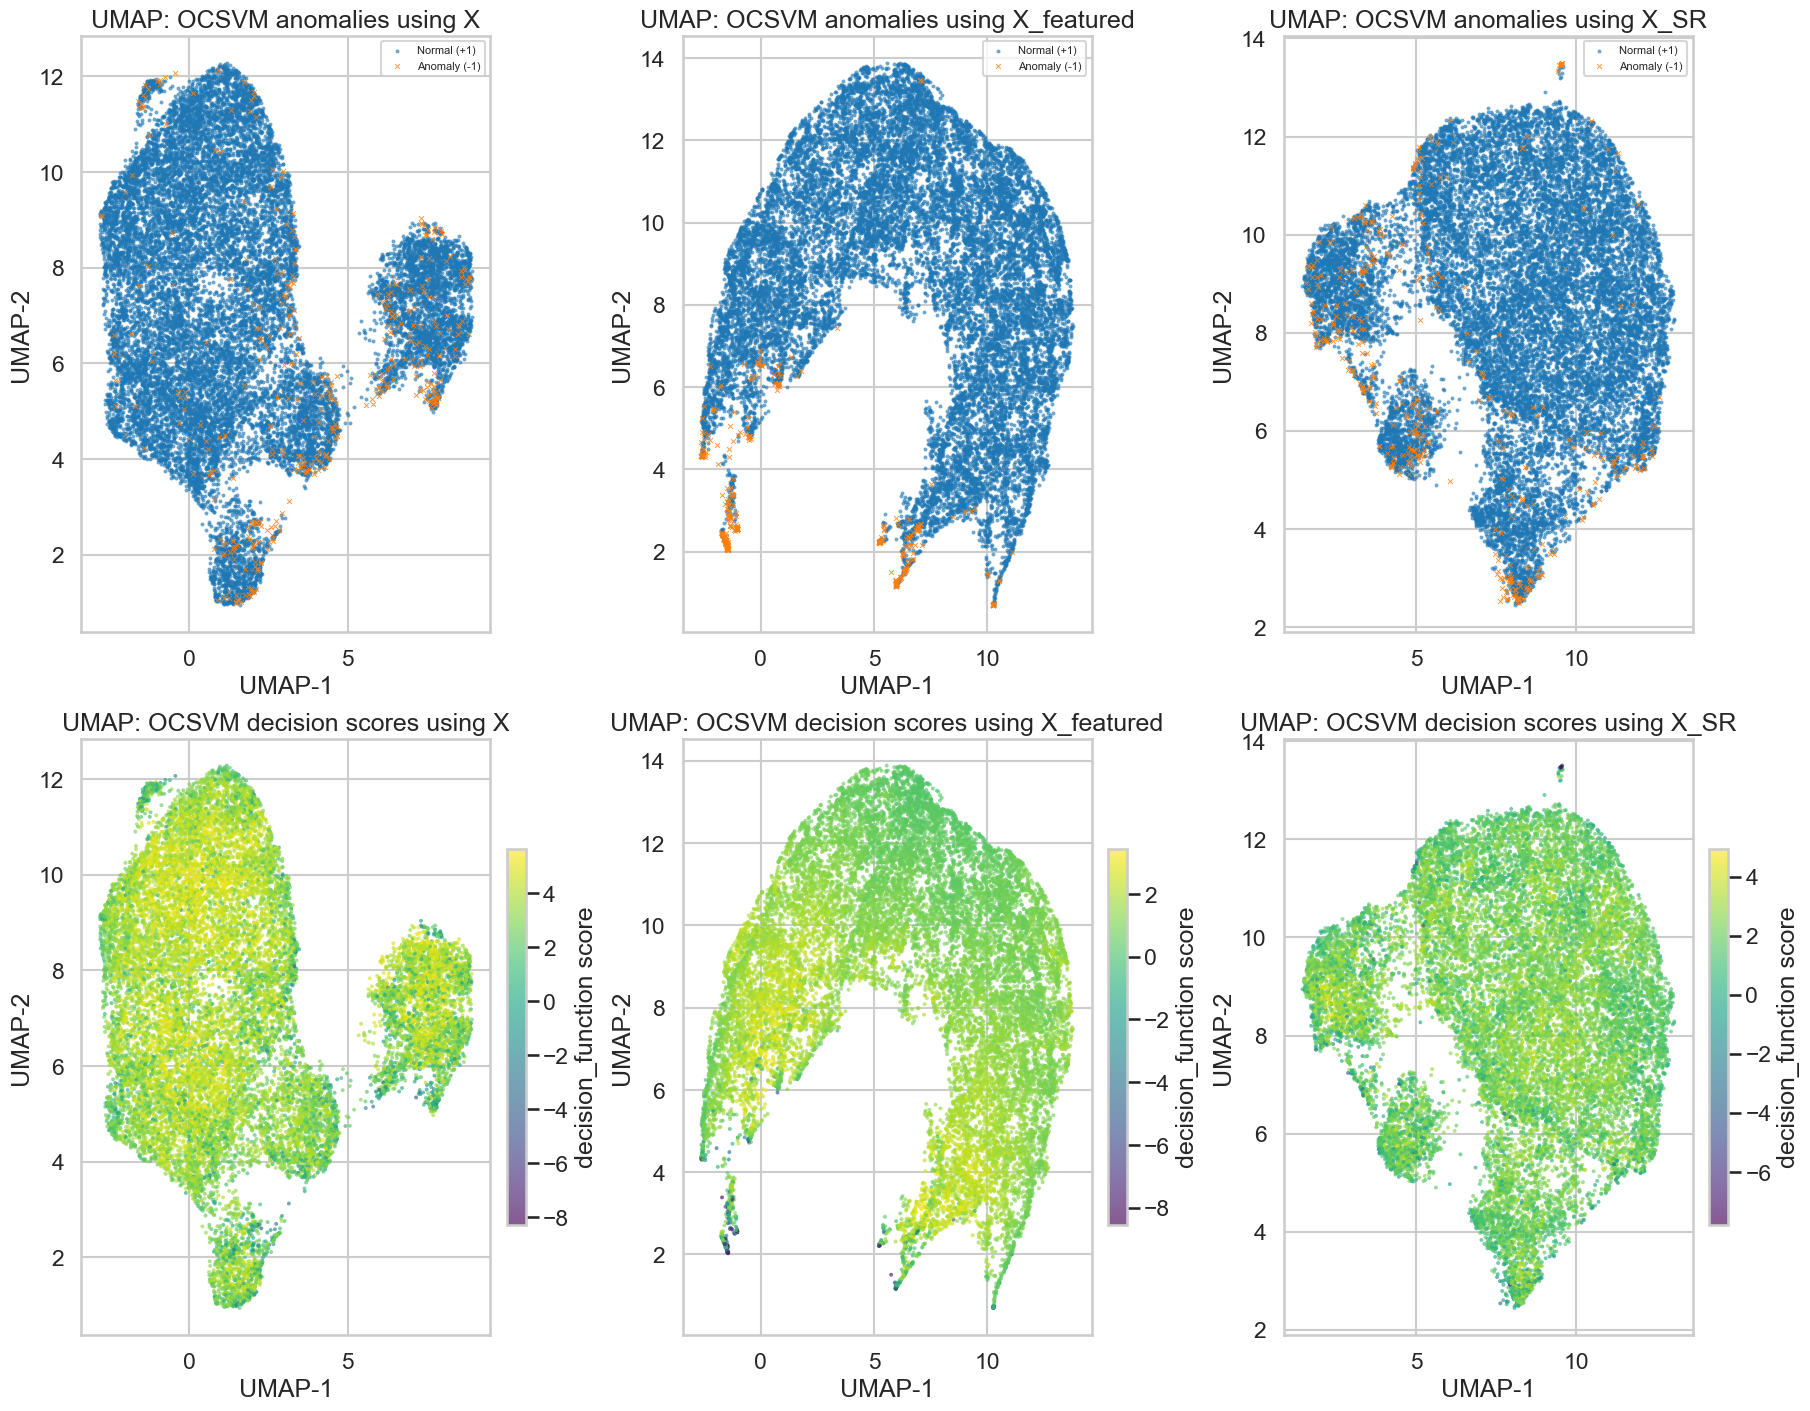

In [120]:
fig, axes = plt.subplots(2, 3, figsize=(18, 14), constrained_layout=True)

for col, ((key, x), (_, y)) in enumerate(zip(X_lib.items(), ocsvm_results.items())):
    if col >= 3:
        break  # only fill 3 columns

    X_data = x[1]
    y_pred = y["y_pred"]
    scores = y["scores"]

    plot_umap_anomalies(
        X_data, y_pred=y_pred,
        title='UMAP: OCSVM anomalies using ' + key,
        ax=axes[0, col]
    )

    plot_umap_anomalies(
        X_data, decision_scores=scores,
        title='UMAP: OCSVM decision scores using ' + key,
        ax=axes[1, col],
        add_colorbar=True
    )

plt.show()

With no infomation regarding true anommolies, we must evaluate the models in other ways. Uniform Manifold Approximation and Projection (UMAP) is a non-linear dimensionality-reduction technique used to visualise high-dimensional data in a low-dimensional space (typically 2D). It constructs a weighted graph that preserves local neighbourhood structure in the original feature space and then optimises a low-dimensional embedding that maintains these relationships. As a result, UMAP is well suited to revealing clusters, manifolds, and boundary regions, making it particularly useful for visualising operating regimes and highlighting anomalous or low-density states in complex datasets.

A higher performing model will exhibit the following:

Binary Anomaly labels (Top Row)
	•	anomalies preferentially on the edges, bridges, tips, sparse regions
	•	not uniformly sprinkled through dense cores

Decision Function Continuous (Bottom Row)
  •	smooth gradients from core → edge
	•	darkest colours concentrated at geometrical extremes
	•	no chaotic speckling in dense regions

Examining the plots, we can clearly see the model using X (the origional feature set) has anomalies scattered throughout dense regions, with many deep inside blue clouds of the Binary plot. Within the Dicision function plot, the is some noise and lack of smooth colour gradient.

The model using X_reduced exhibits better behaviour of anomaly locations within the binary plot, with more appearing around edges and less dense regions, however still some contamination. The decision function plot displays a smoother gradient with a large interior region confidently inlier. The removal of redundent and colinear features helped the OCSVM geometry.

The model using the physics informed, ressidual-based features (X_r_fe), displays the best structure. The binary plot has the most anomaly concentration in less dense regions, rivers, edges of the manafold and the least anomalies spread through the denser regions. The decision boundary plot demonstrates the cleanest gradient of the three models, with darkest regions corresponding to geometric extremes and the interiour region almost entirely high score (high density of inliers).



In [121]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_anomalies(
    X_data,
    X_key,
    anomaly_labels,
    decision_scores=None,
    ax=None,
    point_size=8,
    alpha=0.3,
    add_colorbar=False,
):
    if ax is None:
        ax = plt.gca()

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    if decision_scores is not None:
        sc = ax.scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            c=decision_scores,
            cmap="viridis",
            s=point_size,
            alpha=0.7,
        )
        if add_colorbar:
            cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("OCSVM decision_function score")
    else:
        inlier = anomaly_labels == 1
        outlier = anomaly_labels == -1

        ax.scatter(
            X_pca[inlier, 0],
            X_pca[inlier, 1],
            s=point_size,
            alpha=alpha,
            label="Normal (+1)",
            zorder=1
        )
        ax.scatter(
            X_pca[outlier, 0],
            X_pca[outlier, 1],
            s=point_size,
            alpha=alpha,
            marker="x",
            color="red",
            label="Anomaly (-1)",
            zorder=2
        )
        ax.legend(fontsize=8)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    ax.set_title(f"PCA: {X_key}")
    ax.grid(alpha=0.3)

    return pca, X_pca

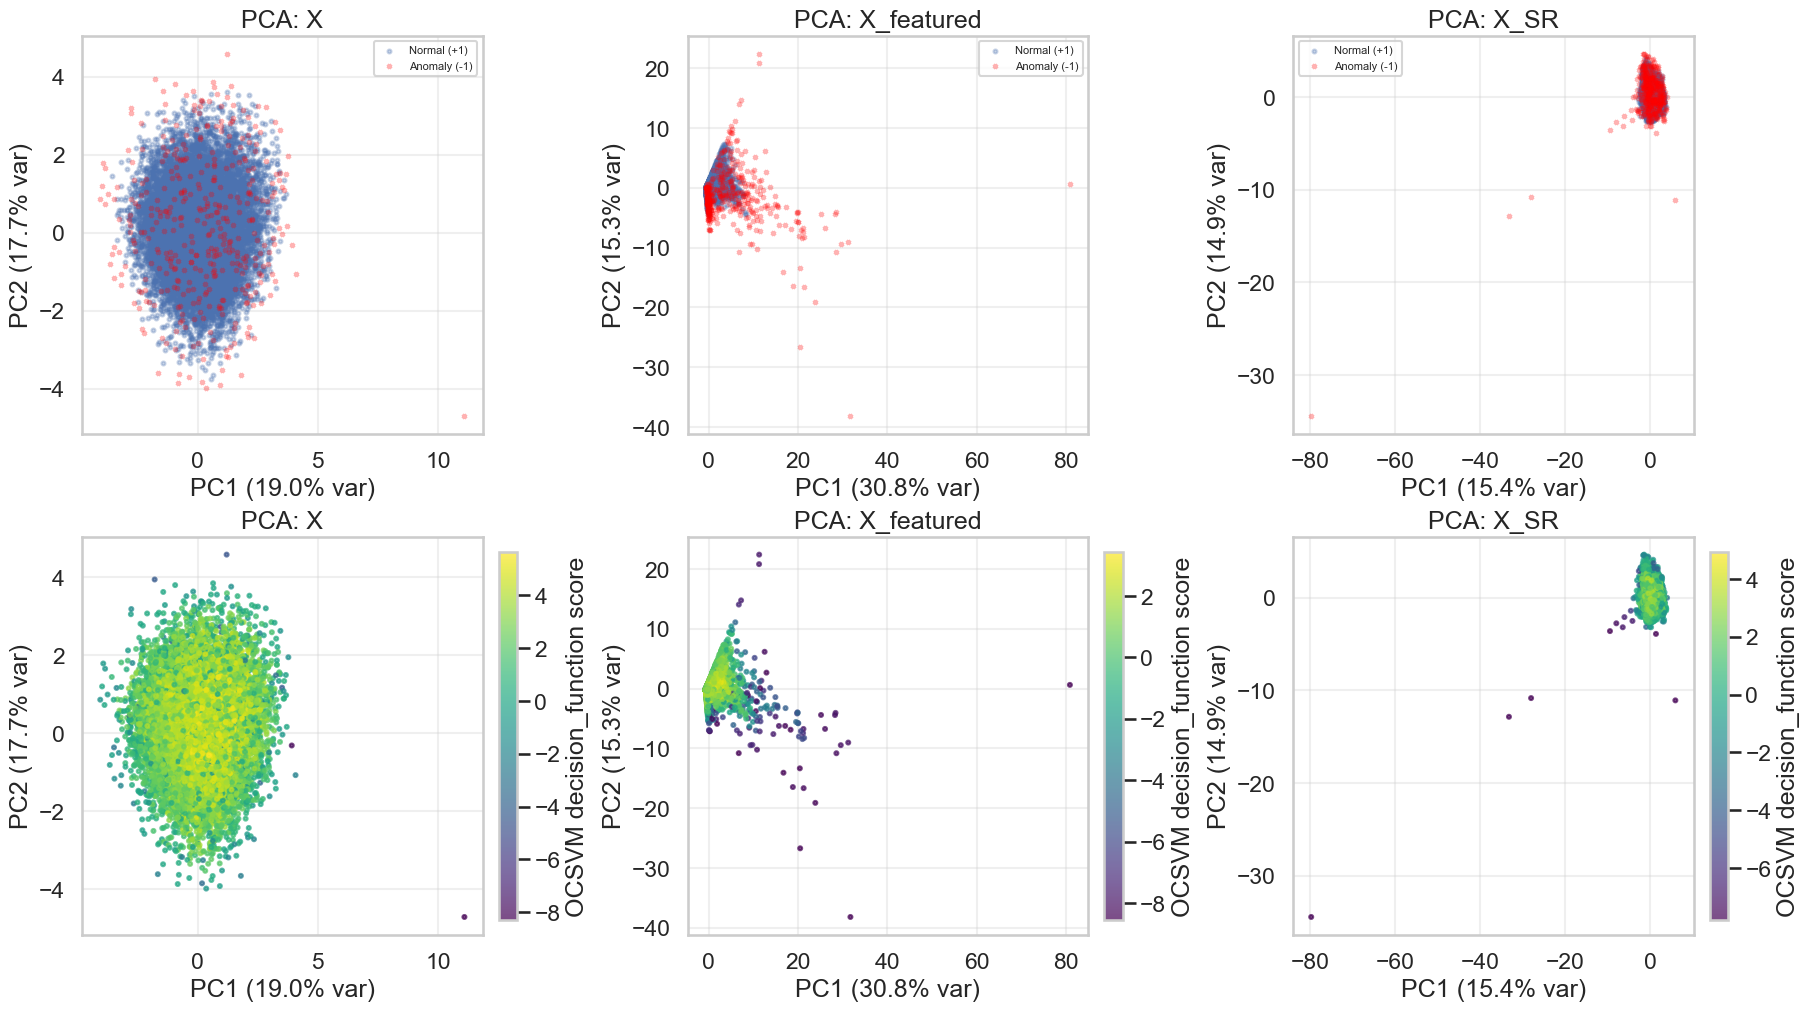

In [123]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for col, ((key, x), (_, y)) in enumerate(zip(X_lib.items(), ocsvm_results.items())):
    if col >= 3:
        break

    X_data = x[1]
    y_pred = y["y_pred"]
    scores = y["scores"]

    # Row 1: anomaly labels
    plot_pca_anomalies(
        X_data=X_data,
        X_key=key,
        anomaly_labels=y_pred,
        ax=axes[0, col]
    )

    # Row 2: decision scores
    plot_pca_anomalies(
        X_data=X_data,
        X_key=key,
        anomaly_labels=y_pred,
        decision_scores=scores,
        ax=axes[1, col],
        add_colorbar=True
    )

plt.show()

Principal Component Analysis (PCA) is a linear dimensionality-reduction technique that projects high-dimensional data onto orthogonal axes (principal components) that maximise variance. Unlike UMAP, PCA does not preserve non-linear neighbourhood structure, but instead reveals how variance is distributed across linear combinations of features. As such, PCA is particularly useful for assessing whether anomalies correspond to directions of unusually large variance and for understanding how feature engineering reshapes the geometry of the data.

A higher performing anomaly model, when viewed through PCA, will exhibit the following characteristics:

Binary Anomaly Labels (Top Row)
	•	anomalies appearing preferentially at the periphery of the main cluster
	•	limited overlap between normal and anomalous points
	•	minimal contamination of the dense core by anomalies

Decision Function Continuous (Bottom Row)
	•	a clear gradient in decision function scores aligned with distance from the core
	•	low scores concentrated at extremes of principal components
	•	a stable, high-confidence inlier region near the centre

Original Feature Set (X)

Examining the PCA projection for the original scaled features, anomalies are heavily interspersed throughout the dense central region of the data cloud. The binary plot shows significant overlap between normal and anomalous points, with no clear separation along the first two principal components.

In the decision-function plot, scores vary weakly across the projection and do not align strongly with distance from the centre. This indicates that the dominant variance directions captured by PCA are not well aligned with the anomaly structure learned by the OCSVM. Anomalies in this representation are therefore subtle, local deviations rather than distinct operating regimes.

⸻

Reduced Feature Set (X_reduced)

The PCA projection of the reduced feature set shows a more compact and symmetric data cloud, with principal components explaining a higher proportion of variance. In the binary plot, anomalies are more frequently observed towards the outer regions of the cluster, though overlap with the core remains.

The decision-function plot exhibits a smoother gradient compared to the original feature set, with a clearer distinction between high-confidence inliers near the centre and lower-score points towards the edges. This improvement reflects the removal of redundant and colinear features, allowing PCA and the OCSVM to align more closely with meaningful structure in the data.

⸻

Physics-Informed Feature Set (X_reduced_featured)

The PCA projection of the physics-informed, residual-based feature set exhibits a markedly different structure. Normal operating states collapse into a tight, high-density cluster, while anomalous observations appear far from the core along the principal component axes.

This behaviour arises because residual-based features encode violations of learned physical relationships, which introduce high variance specifically for anomalous points. As PCA maximises variance, these violations dominate the principal components, resulting in strong spatial separation.

The binary plot shows minimal contamination of the dense core by anomalies, and the decision-function plot demonstrates a clear gradient, with the lowest scores located at the most extreme projections. This indicates strong alignment between variance structure, physical inconsistency, and anomaly detection.

In [124]:
# Parameters to try with the isolation forest

param_grid = [
    {"contamination": 0.02, "n_estimators": 300, "max_samples": 256, "max_features": 1.0},
    {"contamination": 0.03, "n_estimators": 300, "max_samples": 256, "max_features": 1.0},
    {"contamination": 0.04, "n_estimators": 300, "max_samples": 256, "max_features": 1.0},
    {"contamination": 0.05, "n_estimators": 300, "max_samples": 256, "max_features": 1.0},
    {"contamination": 0.02, "n_estimators": 500, "max_samples": 512, "max_features": 1.0},
    {"contamination": 0.03, "n_estimators": 500, "max_samples": 512, "max_features": 1.0},
    {"contamination": 0.04, "n_estimators": 500, "max_samples": 512, "max_features": 1.0},
    {"contamination": 0.05, "n_estimators": 500, "max_samples": 512, "max_features": 1.0},
]

In [125]:
# Loop to try each parameter set with each X_scaled dataset and store in a results library
from sklearn.ensemble import IsolationForest

tree_results = {}

for key, x in X_lib.items():
    X_data = x[0]
    columns = x[2]

    best_sep = -np.inf
    best_result = None

    for param in param_grid:
        iso_forest = IsolationForest(**param, random_state=42)
        iso_forest.fit(X_data)

        y_pred = iso_forest.predict(X_data)
        scores = iso_forest.decision_function(X_data)

        df_out = pd.DataFrame(X_data, columns=columns)
        df_out["anomaly"] = y_pred
        df_out["score"] = scores

        anomalies = df_out[df_out["anomaly"] == -1]
        
        # Separation metric to evaluate each model and feature set
        sep = (
            scores[y_pred == 1].mean() - scores[y_pred == -1].mean()
        ) / scores.std()

        # Store result if it has the best separation so far
        if sep > best_sep:
            best_sep = sep
            best_result = {
                "params": param,
                "y_pred": y_pred,
                "scores": scores,
                "df": df_out,
                "anomalies": anomalies,
                "separation": sep
            }

        print(
            f"[IF] {key} | {param} → "
            f"{anomalies.shape[0]} anomalies "
            f"({anomalies.shape[0] / len(X_data):.2%}) "
            f"separation {sep:.2f}"
        )
    
    # Store only the best result for this key
    tree_results[key] = best_result
    print(f"\nBest for {key}: separation = {best_sep:.2f}\n")

[IF] X | {'contamination': 0.02, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0} → 391 anomalies (2.00%) separation 3.00
[IF] X | {'contamination': 0.03, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0} → 587 anomalies (3.00%) separation 2.82
[IF] X | {'contamination': 0.04, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0} → 782 anomalies (4.00%) separation 2.70
[IF] X | {'contamination': 0.05, 'n_estimators': 300, 'max_samples': 256, 'max_features': 1.0} → 977 anomalies (5.00%) separation 2.60
[IF] X | {'contamination': 0.02, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0} → 391 anomalies (2.00%) separation 3.10
[IF] X | {'contamination': 0.03, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0} → 587 anomalies (3.00%) separation 2.91
[IF] X | {'contamination': 0.04, 'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0} → 782 anomalies (4.00%) separation 2.77
[IF] X | {'contamination': 0.05, 'n_estimators': 500, '

If we examine the mean seperation distance of each configuration and each feature set, the combonation witht he highest separation is confgiuration 5 with X_reduced_features (mean separation 3.40), very closely followed by configuration 5 with X_reduced (3.34). In all three feature sets, the best performing based on the mean seperation distance is configuration 5. therefore lets proceed with plotting only for the first configuation.

/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no 

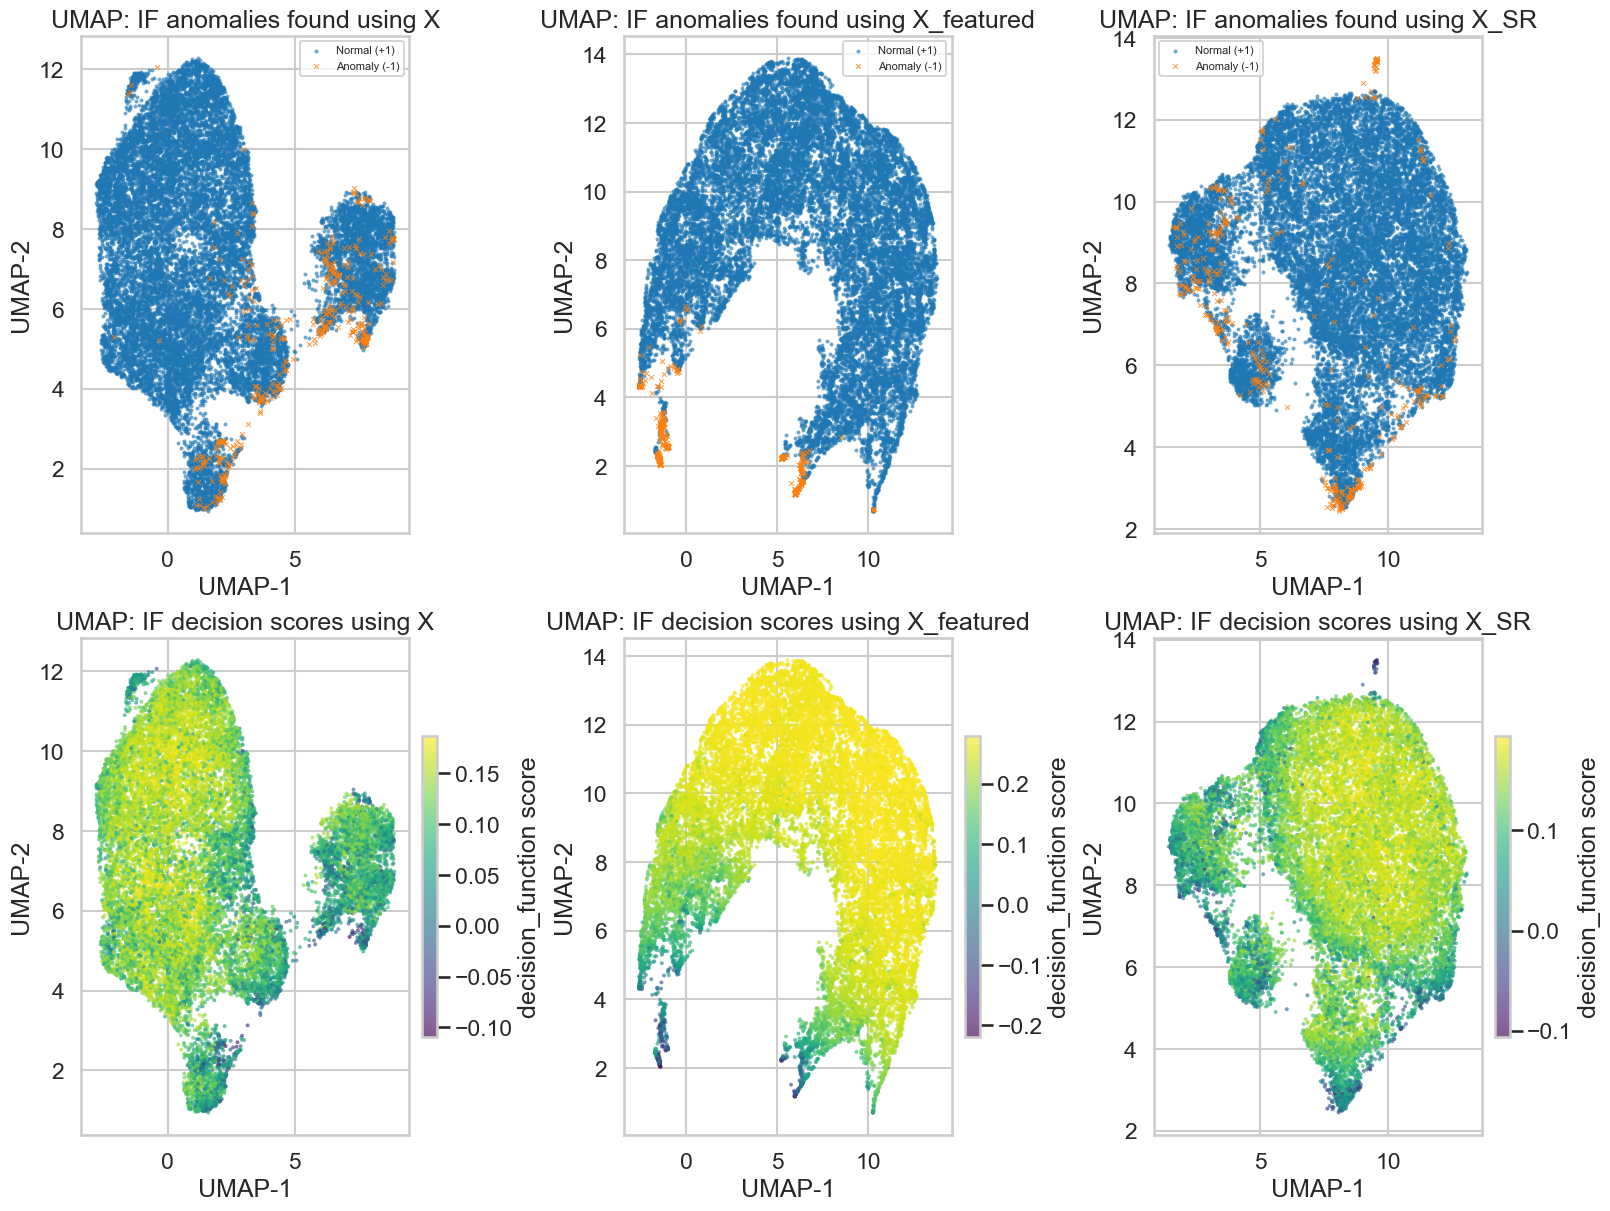

In [126]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12), constrained_layout=True)

for col, ((key, x), (_, y)) in enumerate(zip(X_lib.items(), tree_results.items())):
    if col >= 3:
        break  # only fill 3 columns

    X_data = x[1]
    y_pred = y["y_pred"]
    scores = y["scores"]

    plot_umap_anomalies(
        X_data, y_pred=y_pred,
        title='UMAP: IF anomalies found using ' + key,
        ax=axes[0, col]
    )

    plot_umap_anomalies(
        X_data, decision_scores=scores,
        title='UMAP: IF decision scores using ' + key,
        ax=axes[1, col],
        add_colorbar=True
    )

plt.show()

In [127]:
X_lib

{'X': [array([[ 682.        ,    2.39165593,    4.61719583,    2.84898211,
            76.27241676,   69.88460898],
         [ 605.        ,    5.46687695,    6.42436074,    5.72752018,
            73.22267936,   74.90731428],
         [ 658.        ,    3.43423224,    3.68089632,    1.67870822,
            88.08991608,   78.70480574],
         ...,
         [ 616.        ,    3.31004843,    3.78769277,    6.00103089,
            75.88980991,   72.22000922],
         [1163.        ,    2.73172559,    3.70359526,    2.95168439,
            76.78462566,   81.40008837],
         [ 695.        ,    2.51508914,    6.3554619 ,    2.68856724,
            77.55591819,   71.15608059]], shape=(19535, 6)),
  array([[-0.40821185, -0.89281929, -0.73830371,  0.49559555, -0.44070891,
          -1.37641176],
         [-0.69595007,  2.11733175, -0.08375911,  3.27315389, -1.42104681,
          -0.56715821],
         [-0.49789649,  0.12769669, -1.07742594, -0.63362488,  3.35802552,
           0.04469003]

# Results


In [128]:


def combine_results(df, iqr_bound):
  results_df = df.copy()

  # IQR: anomaly if count >= iqr_bound
  # 1 anomaly, 0 normal
  results_df["IQR_anom"] = (results_df["count"] >= iqr_bound).astype(int)  

  # OCSVM predictions are +1 normal, -1 anomaly
  results_df["OCSVM_anom"] = (ocsvm_results[key]["y_pred"] == -1).astype(int)

  # IF predictions are +1 normal, -1 anomaly
  results_df["IF_anom"] = (tree_results[key]["y_pred"] == -1).astype(int)

  # Confluence: number of methods that flagged this row 
  results_df["Confluence"] = results_df[["IQR_anom", "OCSVM_anom", "IF_anom"]].sum(axis=1)

  # Summary table (counts of rows flagged by 0/1/2/3 methods)
  confluence_counts = results_df["Confluence"].value_counts().reindex([0,1,2,3], fill_value=0)
  results_confluence = confluence_counts.to_frame(name="RowCount").T
  results_confluence.columns = [
      "Predicted by No Model",
      "Predicted by One Model",
      "Predicted by Two Models",
      "Predicted by Three Models",
  ]

  print(results_df[['IQR_anom', 'OCSVM_anom', 'IF_anom', 'Confluence']][results_df['count'] >= iqr_bound])
  
  return results_df

In [129]:
iqr_bound = [2, 5, 5]
results_list = []
for n, df_iqr in zip(iqr_bound, df_iqr_list):
  result = combine_results(df_iqr, n)
  results_list.append(result)

       IQR_anom  OCSVM_anom  IF_anom  Confluence
1             1           0        0           1
2             1           0        0           1
6             1           0        0           1
7             1           0        0           1
8             1           0        0           1
...         ...         ...      ...         ...
19516         1           0        0           1
19526         1           0        0           1
19528         1           0        0           1
19529         1           0        0           1
19532         1           0        0           1

[4636 rows x 4 columns]
       IQR_anom  OCSVM_anom  IF_anom  Confluence
7             1           0        0           1
9             1           1        0           2
13            1           0        0           1
113           1           0        0           1
115           1           1        0           2
...         ...         ...      ...         ...
19381         1           0        0        

In [130]:
for key in X_lib.keys():
  sep1 = ocsvm_results[key]["separation"]
  sep2 = tree_results[key]["separation"]
  
  print(f"Separation for dataset {key} using OCSVM {sep1}")
  print(f"Separation for dataset {key} using IF {sep2}")
  

Separation for dataset X using OCSVM 3.3624521017945144
Separation for dataset X using IF 3.0958661186293925
Separation for dataset X_featured using OCSVM 4.524383913111559
Separation for dataset X_featured using IF 4.602800652002928
Separation for dataset X_SR using OCSVM 3.285884308944425
Separation for dataset X_SR using IF 3.376383656252156


# Evaluation

## Feature-set evaluation: margin, density, agreement, robustness

Unsupervised evaluation metrics for OCSVM and IsolationForest across feature sets:
1. **Margin statistics** – decision function separation between predicted classes
2. **Density contrast** – kNN-based local density difference
3. **Cross-model agreement** – Jaccard, coverage, Spearman rank correlation
4. **Robustness** – sensitivity to hyperparameter sweeps

In [131]:
from typing import Dict, Any, Tuple, List, Optional
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

In [132]:
def decision_margin(
    scores: np.ndarray,
    labels: np.ndarray
) -> Dict[str, float]:
    """
    Compute decision-function margin statistics.
    
    Parameters
    ----------
    scores : array-like, decision_function output
    labels : array-like, +1 (normal) or -1 (anomaly)
    
    Returns
    -------
    dict with mu_normal, mu_anomaly, raw_margin, norm_margin
    """
    scores = np.asarray(scores)
    labels = np.asarray(labels)
    
    mask_normal = (labels == 1)
    mask_anomaly = (labels == -1)
    
    if not mask_normal.any() or not mask_anomaly.any():
        return {
            "mu_normal": np.nan,
            "mu_anomaly": np.nan,
            "raw_margin": np.nan,
            "norm_margin": np.nan
        }
    
    mu_normal = float(scores[mask_normal].mean())
    mu_anomaly = float(scores[mask_anomaly].mean())
    std_normal = float(scores[mask_normal].std())
    
    raw_margin = mu_normal - mu_anomaly
    norm_margin = raw_margin / std_normal if std_normal > 1e-9 else np.nan
    
    return {
        "mu_normal": mu_normal,
        "mu_anomaly": mu_anomaly,
        "raw_margin": raw_margin,
        "norm_margin": norm_margin
    }

In [133]:
def density_contrast(
    X: np.ndarray,
    labels: np.ndarray,
    k: int = 15
) -> Dict[str, float]:
    """
    Compute local density contrast via kNN mean distance.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    labels : array-like, +1 (normal) or -1 (anomaly)
    k : int, number of neighbors (default 15)
    
    Returns
    -------
    dict with mean_density_normal, mean_density_anomaly, density_contrast
    """
    X = np.asarray(X)
    labels = np.asarray(labels)
    
    mask_normal = (labels == 1)
    mask_anomaly = (labels == -1)
    
    if not mask_normal.any() or not mask_anomaly.any():
        return {
            "mean_density_normal": np.nan,
            "mean_density_anomaly": np.nan,
            "density_contrast": np.nan
        }
    
    # Fit kNN on all data
    k_use = min(k + 1, X.shape[0])  # +1 because query includes self
    nn = NearestNeighbors(n_neighbors=k_use, algorithm='auto')
    nn.fit(X)
    
    # Compute mean distance to k neighbors (exclude self at index 0)
    distances, _ = nn.kneighbors(X)
    mean_dist = distances[:, 1:].mean(axis=1)  # exclude self
    
    mean_density_normal = float(mean_dist[mask_normal].mean())
    mean_density_anomaly = float(mean_dist[mask_anomaly].mean())
    
    return {
        "mean_density_normal": mean_density_normal,
        "mean_density_anomaly": mean_density_anomaly,
        "density_contrast": mean_density_anomaly - mean_density_normal
    }

In [134]:
def agreement_metrics(
    labels_ocsvm: np.ndarray,
    labels_if: np.ndarray,
    scores_ocsvm: Optional[np.ndarray] = None,
    scores_if: Optional[np.ndarray] = None
) -> Dict[str, float]:
    """
    Compute cross-model anomaly agreement metrics.
    
    Parameters
    ----------
    labels_ocsvm : array-like, +1 or -1 from OCSVM
    labels_if : array-like, +1 or -1 from IsolationForest
    scores_ocsvm : optional, decision scores from OCSVM
    scores_if : optional, decision scores from IF
    
    Returns
    -------
    dict with jaccard, coverage_oc_to_if, coverage_if_to_oc, spearman_rho
    """
    labels_ocsvm = np.asarray(labels_ocsvm)
    labels_if = np.asarray(labels_if)
    
    A_oc = set(np.where(labels_ocsvm == -1)[0])
    A_if = set(np.where(labels_if == -1)[0])
    
    inter = A_oc & A_if
    union = A_oc | A_if
    
    jaccard = len(inter) / len(union) if len(union) > 0 else 0.0
    coverage_oc_to_if = len(inter) / len(A_oc) if len(A_oc) > 0 else 0.0
    coverage_if_to_oc = len(inter) / len(A_if) if len(A_if) > 0 else 0.0
    
    # Spearman rank correlation on anomaly scores
    # For OCSVM: more negative = more anomalous → negate for "anomaly score"
    # For IF: more negative = more anomalous → negate for "anomaly score"
    spearman_rho = np.nan
    if scores_ocsvm is not None and scores_if is not None:
        anom_score_oc = -np.asarray(scores_ocsvm)  # higher = more anomalous
        anom_score_if = -np.asarray(scores_if)     # higher = more anomalous
        rho, _ = spearmanr(anom_score_oc, anom_score_if)
        spearman_rho = float(rho)
    
    return {
        "intersection": len(inter),
        "union": len(union),
        "jaccard": jaccard,
        "coverage_oc_to_if": coverage_oc_to_if,
        "coverage_if_to_oc": coverage_if_to_oc,
        "spearman_rho": spearman_rho
    }

In [135]:
def separation_metric(
    X: np.ndarray,
    labels: np.ndarray
) -> float:
    """
    Compute centroid-based separation: Euclidean distance between class centroids.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
    labels : array-like, +1 (normal) or -1 (anomaly)
    
    Returns
    -------
    float, Euclidean distance between centroids
    """
    X = np.asarray(X)
    labels = np.asarray(labels)
    
    mask_normal = (labels == 1)
    mask_anomaly = (labels == -1)
    
    if not mask_normal.any() or not mask_anomaly.any():
        return np.nan
    
    centroid_normal = X[mask_normal].mean(axis=0)
    centroid_anomaly = X[mask_anomaly].mean(axis=0)
    
    return float(np.linalg.norm(centroid_normal - centroid_anomaly))

In [136]:
def robustness_sweep_ocsvm(
    X_raw: np.ndarray,
    nu_grid: np.ndarray = None,
    gamma: float = 0.5,
    random_state: int = 42
) -> Dict[str, Any]:
    """
    Sweep OCSVM over nu values and measure separation robustness.
    
    Parameters
    ----------
    X_raw : array-like, raw features (will be scaled internally)
    nu_grid : array-like, nu values to sweep (default linspace(0.01, 0.05, 10))
    gamma : float, RBF kernel gamma
    random_state : int
    
    Returns
    -------
    dict with mean_separation, separation_var, separations, anomaly_rates
    """
    if nu_grid is None:
        nu_grid = np.linspace(0.01, 0.05, 10)
    
    X_raw = np.asarray(X_raw)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    separations = []
    anomaly_rates = []
    
    for nu in nu_grid:
        try:
            model = OneClassSVM(kernel='rbf', gamma=gamma, nu=nu)
            model.fit(X_scaled)
            labels = model.predict(X_scaled)
            
            n_anom = (labels == -1).sum()
            n_norm = (labels == 1).sum()
            
            if n_anom == 0 or n_norm == 0:
                continue
            
            sep = separation_metric(X_scaled, labels)
            separations.append(sep)
            anomaly_rates.append(n_anom / len(labels))
        except Exception:
            continue
    
    if len(separations) == 0:
        return {
            "mean_separation": np.nan,
            "separation_var": np.nan,
            "separations": [],
            "anomaly_rates": []
        }
    
    return {
        "mean_separation": float(np.mean(separations)),
        "separation_var": float(np.var(separations)),
        "separations": separations,
        "anomaly_rates": anomaly_rates
    }


def robustness_sweep_if(
    X_raw: np.ndarray,
    contamination_grid: np.ndarray = None,
    n_estimators: int = 100,
    random_state: int = 42
) -> Dict[str, Any]:
    """
    Sweep IsolationForest over contamination values and measure separation robustness.
    
    Parameters
    ----------
    X_raw : array-like, raw features
    contamination_grid : array-like, contamination values to sweep
    n_estimators : int, number of trees
    random_state : int
    
    Returns
    -------
    dict with mean_separation, separation_var, separations, anomaly_rates
    """
    if contamination_grid is None:
        contamination_grid = np.linspace(0.01, 0.05, 10)
    
    X_raw = np.asarray(X_raw)
    
    separations = []
    anomaly_rates = []
    
    for cont in contamination_grid:
        try:
            model = IsolationForest(
                contamination=cont,
                n_estimators=n_estimators,
                random_state=random_state
            )
            model.fit(X_raw)
            labels = model.predict(X_raw)
            
            n_anom = (labels == -1).sum()
            n_norm = (labels == 1).sum()
            
            if n_anom == 0 or n_norm == 0:
                continue
            
            sep = separation_metric(X_raw, labels)
            separations.append(sep)
            anomaly_rates.append(n_anom / len(labels))
        except Exception:
            continue
    
    if len(separations) == 0:
        return {
            "mean_separation": np.nan,
            "separation_var": np.nan,
            "separations": [],
            "anomaly_rates": []
        }
    
    return {
        "mean_separation": float(np.mean(separations)),
        "separation_var": float(np.var(separations)),
        "separations": separations,
        "anomaly_rates": anomaly_rates
    }

In [137]:
def evaluate_feature_sets(
    X_lib: Dict[str, List],
    ocsvm_results: Dict[str, Dict],
    tree_results: Dict[str, Dict],
    k_density: int = 15,
    gamma_ocsvm: float = 0.5,
    n_estimators_if: int = 100
) -> pd.DataFrame:
    """
    Run all unsupervised evaluation metrics for each feature set.
    
    Parameters
    ----------
    X_lib : dict, {key: [X_raw, X_scaled, columns]}
    ocsvm_results : dict, {key: {y_pred, scores, ...}}
    tree_results : dict, {key: {y_pred, scores, ...} or list of dicts}
    k_density : int, k for kNN density contrast
    gamma_ocsvm : float, gamma for OCSVM robustness sweep
    n_estimators_if : int, n_estimators for IF robustness sweep
    
    Returns
    -------
    pd.DataFrame with one row per feature set
    """
    rows = []
    
    for key in X_lib.keys():
        print(f"Evaluating: {key}")
        
        # Get data
        x_data = X_lib[key]
        X_raw = np.asarray(x_data[0])
        X_scaled = np.asarray(x_data[1])
        
        # Get OCSVM results
        oc_res = ocsvm_results.get(key)
        if isinstance(oc_res, (list, tuple)):
            oc_labels = np.asarray(oc_res[0])
            oc_scores = np.asarray(oc_res[1])
        elif isinstance(oc_res, dict):
            oc_labels = np.asarray(oc_res.get("y_pred"))
            oc_scores = np.asarray(oc_res.get("scores"))
        else:
            oc_labels, oc_scores = None, None
        
        # Get IF results (handle list or dict)
        if_res = tree_results.get(key)
        if isinstance(if_res, list):
            # Pick best by separation
            best = max(if_res, key=lambda d: d.get("separation", -np.inf))
            if_labels = np.asarray(best.get("y_pred"))
            if_scores = np.asarray(best.get("scores"))
        elif isinstance(if_res, dict):
            if_labels = np.asarray(if_res.get("y_pred"))
            if_scores = np.asarray(if_res.get("scores"))
        else:
            if_labels, if_scores = None, None
        
        row = {"feature_set": key}
        
        # ===== (i) Margin statistics =====
        if oc_labels is not None and oc_scores is not None:
            oc_margin = decision_margin(oc_scores, oc_labels)
            row["ocsvm_raw_margin"] = oc_margin["raw_margin"]
            row["ocsvm_norm_margin"] = oc_margin["norm_margin"]
            row["ocsvm_anom_rate"] = (oc_labels == -1).mean()
        
        if if_labels is not None and if_scores is not None:
            if_margin = decision_margin(if_scores, if_labels)
            row["if_raw_margin"] = if_margin["raw_margin"]
            row["if_norm_margin"] = if_margin["norm_margin"]
            row["if_anom_rate"] = (if_labels == -1).mean()
        
        # ===== (ii) Density contrast =====
        # OCSVM uses scaled features
        if oc_labels is not None:
            oc_density = density_contrast(X_scaled, oc_labels, k=k_density)
            row["ocsvm_density_contrast"] = oc_density["density_contrast"]
        
        # IF uses raw features
        if if_labels is not None:
            if_density = density_contrast(X_raw, if_labels, k=k_density)
            row["if_density_contrast"] = if_density["density_contrast"]
        
        # ===== (iii) Cross-model agreement =====
        if oc_labels is not None and if_labels is not None:
            agree = agreement_metrics(oc_labels, if_labels, oc_scores, if_scores)
            row["jaccard"] = agree["jaccard"]
            row["coverage_oc_to_if"] = agree["coverage_oc_to_if"]
            row["coverage_if_to_oc"] = agree["coverage_if_to_oc"]
            row["spearman_rho"] = agree["spearman_rho"]
        
        # ===== (iv) Robustness sweeps =====
        print(f"  Running OCSVM robustness sweep...")
        oc_robust = robustness_sweep_ocsvm(X_raw, gamma=gamma_ocsvm)
        row["ocsvm_robust_mean_sep"] = oc_robust["mean_separation"]
        row["ocsvm_robust_var"] = oc_robust["separation_var"]
        
        print(f"  Running IF robustness sweep...")
        if_robust = robustness_sweep_if(X_raw, n_estimators=n_estimators_if)
        row["if_robust_mean_sep"] = if_robust["mean_separation"]
        row["if_robust_var"] = if_robust["separation_var"]
        
        rows.append(row)
    
    return pd.DataFrame(rows)

In [138]:
# Run the full evaluation
print("=" * 60)
print("Feature-set Evaluation: Margin, Density, Agreement, Robustness")
print("=" * 60)

metrics_df = evaluate_feature_sets(
    X_lib=X_lib,
    ocsvm_results=ocsvm_results,
    tree_results=tree_results,
    k_density=15,
    gamma_ocsvm=0.5,
    n_estimators_if=100
)

# Reorder columns for clarity
col_order = [
    "feature_set",
    # OCSVM metrics
    "ocsvm_raw_margin", "ocsvm_norm_margin", "ocsvm_density_contrast",
    "ocsvm_robust_mean_sep", "ocsvm_robust_var", "ocsvm_anom_rate",
    # IF metrics
    "if_raw_margin", "if_norm_margin", "if_density_contrast",
    "if_robust_mean_sep", "if_robust_var", "if_anom_rate",
    # Agreement metrics
    "jaccard", "coverage_oc_to_if", "coverage_if_to_oc", "spearman_rho"
]
col_order = [c for c in col_order if c in metrics_df.columns]
metrics_df = metrics_df[col_order]

print("\n" + "=" * 60)
print("Results Summary")
print("=" * 60)
display(metrics_df.round(4))

# Save to CSV
output_path = "feature_set_comparison_metrics.csv"
metrics_df.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

Feature-set Evaluation: Margin, Density, Agreement, Robustness
Evaluating: X


  Running OCSVM robustness sweep...
  Running IF robustness sweep...
Evaluating: X_featured
  Running OCSVM robustness sweep...
  Running IF robustness sweep...
Evaluating: X_SR
  Running OCSVM robustness sweep...
  Running IF robustness sweep...

Results Summary


,feature_set,ocsvm_raw_margin,ocsvm_norm_margin,ocsvm_density_contrast,ocsvm_robust_mean_sep,ocsvm_robust_var,ocsvm_anom_rate,if_raw_margin,if_norm_margin,if_density_contrast,if_robust_mean_sep,if_robust_var,if_anom_rate,jaccard,coverage_oc_to_if,coverage_if_to_oc,spearman_rho
0,X,4.4107,3.8030,0.9064,1.0661,0.0030,0.0199,0.1422,3.4090,5.5420,211.4145,303.9935,0.02,0.4634,0.6350,0.6317,0.7904
1,X_featured,4.2549,6.9184,3.9484,4.4930,0.2059,0.0202,0.3086,6.0216,1.2524,2.9720,0.4029,0.02,0.5472,0.7038,0.7110,-0.4875
2,X_SR,3.1302,3.7942,1.5056,1.4910,0.0038,0.0206,0.1597,3.8056,16.3797,124.9470,213.6731,0.02,0.4161,0.5796,0.5959,0.4006



Saved to: feature_set_comparison_metrics.csv


In [139]:
# Styled display for better readability
def highlight_best(s):
    """Highlight max values in green, min in red for relevant columns."""
    if s.name in ["ocsvm_robust_var", "if_robust_var"]:
        # Lower variance is better
        is_best = s == s.min()
    elif "margin" in s.name or "contrast" in s.name or "sep" in s.name or "jaccard" in s.name or "spearman" in s.name:
        # Higher is better
        is_best = s == s.max()
    else:
        return [""] * len(s)
    return ["background-color: #d4edda" if v else "" for v in is_best]

styled = metrics_df.style.apply(highlight_best, axis=0).format(precision=4)
display(styled)

,feature_set,ocsvm_raw_margin,ocsvm_norm_margin,ocsvm_density_contrast,ocsvm_robust_mean_sep,ocsvm_robust_var,ocsvm_anom_rate,if_raw_margin,if_norm_margin,if_density_contrast,if_robust_mean_sep,if_robust_var,if_anom_rate,jaccard,coverage_oc_to_if,coverage_if_to_oc,spearman_rho
0,X,4.4107,3.8030,0.9064,1.0661,0.0030,0.0199,0.1422,3.4090,5.5420,211.4145,303.9935,0.0200,0.4634,0.6350,0.6317,0.7904
1,X_featured,4.2549,6.9184,3.9484,4.4930,0.2059,0.0202,0.3086,6.0216,1.2524,2.9720,0.4029,0.0200,0.5472,0.7038,0.7110,-0.4875
2,X_SR,3.1302,3.7942,1.5056,1.4910,0.0038,0.0206,0.1597,3.8056,16.3797,124.9470,213.6731,0.0200,0.4161,0.5796,0.5959,0.4006


# Evaluation Summary

This work examined how feature representation affects unsupervised anomaly detection in ship-engine sensor data. The models were held fixed, and three feature sets were compared: raw sensor values, statistically reduced features, and features derived through symbolic regression. Anomaly prevalence was controlled across all experiments, so differences reflect changes in representation rather than detection rate.

The results show that feature choice significantly alters the structure of the problem. Statistical feature reduction produced the strongest geometric separation and density contrast, but was more sensitive to hyperparameter selection. Symbolic features did not maximise separation, but consistently improved normalised decision margins and showed the greatest stability under hyperparameter variation.

Density-based analysis indicated that symbolic features better concentrate normal operating states and isolate anomalous behaviour without excessive compression. Cross-model agreement decreased slightly with feature engineering, suggesting that anomalies are less driven by shared noise and more by the assumptions of each detection method.

Overall, symbolic regression appears most useful as a stabilising representation of normal system behaviour rather than as a means of maximising anomaly separation. In the absence of labels, robustness and consistency emerge as more defensible evaluation criteria than separation alone.

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]